### Installation

```bash
pip install yfinance gnews torch vaderSentiment
```

### What Each Package Does

| Package | Role | Needs Key? |
|---|---|---|
| `yfinance` | Download historical OHLCV stock data from Yahoo Finance | No |
| `gnews` | Scrape Google News RSS for headlines by keyword and date | No |
| `vaderSentiment` | Rule-based sentiment scorer, works offline, no GPU needed | No |
| `torch` | Build and train RNN / LSTM / GRU models | No |
| `scikit-learn` | MinMaxScaler and evaluation metrics | No |

In [3]:
pip install yfinance gnews torch vaderSentiment

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 16.6 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=0e1164219d524968bf413e0bae124d97db533a15011cbb428b17d42e8dbc91d9
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built sgmllib3k


## 1. Overview & Motivation

Stock prices are shaped by two very different kinds of information:

- **Quantitative signals** — price, volume, returns, moving averages. These are clean numbers that are easy to feed into a model.
- **Qualitative signals** — news articles, earnings announcements, analyst opinions. These are messy text that first need to be converted into numbers (sentiment scores) before a model can use them.

A **Multivariate Time Series (MVTS)** model eats both kinds at once and learns how they interact over time.

### What We Are Building

```
Google News Headlines ──► GNews (free, no key) ──► Sentiment Score ──┐
                                                                        ├──► MVTS Model ──► Next-Day Close
yfinance OHLCV Data ──────────────────────────► Engineered Features ──┘
```

The full pipeline has three stages:

```
Stage 1: Data Collection      Stage 2: Feature Engineering     Stage 3: Modeling
──────────────────────        ──────────────────────────────    ──────────────────
yfinance  ──► stock_df        Returns, MAs, Volume change  ──►  SimpleRNN
GNews     ──► news_df         VADER sentiment score        ──►  SimpleLSTM
                              Merge on Date index          ──►  SimpleGRU
                                                                    │
                                                               Evaluate & Compare
```

### Why RNN, LSTM, and GRU?

Recurrent models process sequences one time step at a time, passing a hidden state forward. This makes them natural fits for time series where yesterday's data influences today's prediction.

| Model | Core Idea | Strength | Weakness |
|---|---|---|---|
| **RNN** | Recurrent hidden state updated at every step | Simple, fast, good baseline | Vanishing gradient on long sequences |
| **LSTM** | Cell state + 3 gates (forget, input, output) | Captures long-range dependencies | More parameters, slower to train |
| **GRU** | Merged state + 2 gates (reset, update) | Fast, fewer params than LSTM | Slightly less expressive than LSTM |

All three have identical PyTorch interfaces — swapping one for another is a single-line change.

---

In [1]:
# ── CONFIG — change these to run on any ticker ────────────────────────────
TICKER     = "AAPL"          # Stock ticker symbol
COMPANY    = "Apple"         # Used as the GNews search keyword
START_DATE = "2024-01-01"    # Start of the data window
END_DATE   = "2026-04-12"    # End of the data window
SEQ_LEN    = 20              # Look-back window: 20 trading days ~ 1 month
BATCH_SIZE = 32
EPOCHS     = 50
LR         = 1e-3
HIDDEN     = 64
LAYERS     = 2
DROPOUT    = 0.2

## 3. Step 1 — Download Daily Stock Data

We use `yfinance` to pull OHLCV (Open, High, Low, Close, Volume) data and add a few simple technical features on top.

```python
import yfinance as yf
import pandas as pd
import numpy as np

stock_df = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)
stock_df = stock_df[["Open", "High", "Low", "Close", "Volume"]].copy()
stock_df.index = pd.to_datetime(stock_df.index)
stock_df.index.name = "Date"

stock_df["Return"]     = stock_df["Close"].pct_change()
stock_df["Range"]      = stock_df["High"] - stock_df["Low"]
stock_df["MA_5"]       = stock_df["Close"].rolling(5).mean()
stock_df["MA_20"]      = stock_df["Close"].rolling(20).mean()
stock_df["Vol_Change"] = stock_df["Volume"].pct_change()

stock_df.dropna(inplace=True)
```

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np

stock_df = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)
stock_df = stock_df[["Open", "High", "Low", "Close", "Volume"]].copy()
stock_df.index = pd.to_datetime(stock_df.index)
stock_df.index.name = "Date"

stock_df["Return"]     = stock_df["Close"].pct_change()
stock_df["Range"]      = stock_df["High"] - stock_df["Low"]
stock_df["MA_5"]       = stock_df["Close"].rolling(5).mean()
stock_df["MA_20"]      = stock_df["Close"].rolling(20).mean()
stock_df["Vol_Change"] = stock_df["Volume"].pct_change()

stock_df.dropna(inplace=True)

[*********************100%***********************]  1 of 1 completed


## 4. Step 2 — Download News Headlines with GNews

### GNews

`gnews` is a lightweight Python package that reads the **Google News RSS feed** — no account, no API key, no rate-limit fees. Google News aggregates articles from thousands of publishers worldwide, making it a rich source for financial headlines.

```
GNews  ──►  Google News RSS  ──►  JSON list of articles
              (free, open)          {title, description, published date, url}
```


```python
from gnews import GNews

GNews(
    language    = "en",    # News language
    country     = "US",    # Country edition of Google News
    max_results = 100,      # Headlines to fetch per query (max ~100)
    start_date  = None,    # (year, month, day) tuple to filter by date
    end_date    = None,    # (year, month, day) tuple to filter by date
)
```

```python
import time
from gnews import GNews

def download_news_gnews(company_name, start, end, max_results=10):
    """
    Fetch daily news headlines using GNews (Google News RSS).
    No API key required.

    Parameters
    ----------
    company_name : str
        Search term, e.g. "Apple AAPL stock"
    start        : str  "YYYY-MM-DD"
    end          : str  "YYYY-MM-DD"
    max_results  : int  headlines per day (1 to 100)

    Returns
    -------
    pd.DataFrame with index=Date, column="Headlines" (list of str)
    """
    date_range = pd.date_range(start=start, end=end, freq="B")  # business days only
    records    = []

    print(f"Fetching news for '{company_name}' from {start} to {end} ...")
    print(f"Total days to fetch: {len(date_range)}\n")

    for i, date in enumerate(date_range):
        # GNews expects start_date / end_date as (year, month, day) tuples
        start_tuple = (date.year,  date.month,  date.day)
        next_day    = date + pd.Timedelta(days=1)
        end_tuple   = (next_day.year, next_day.month, next_day.day)

        gn = GNews(
            language    = "en",
            country     = "US",
            max_results = max_results,
            start_date  = start_tuple,
            end_date    = end_tuple,
        )

        try:
            articles  = gn.get_news(company_name)
            headlines = [a["title"] for a in articles if a.get("title")]
        except Exception as e:
            print(f"  Warning on {date.date()}: {e}")
            headlines = []

        records.append({
            "Date"      : pd.Timestamp(date.strftime("%Y-%m-%d")),
            "Headlines" : headlines,
        })

        # Progress update every 50 days
        if (i + 1) % 50 == 0:
            print(f"  Fetched {i + 1}/{len(date_range)} days ...")

        time.sleep(0.5)   # 0.5 s between requests — be respectful

    news_df = pd.DataFrame(records).set_index("Date")
    print(f"\nDone! News DataFrame shape: {news_df.shape}")
    return news_df


news_df = download_news_gnews(
    company_name = f"{COMPANY} {TICKER} stock",
    start        = START_DATE,
    end          = END_DATE,
    max_results  = 10,
)
```

In [5]:
import time
from gnews import GNews

date_range = pd.date_range(start=START_DATE, end=END_DATE, freq="B")
records = []

for i, date in enumerate(date_range):
    next_day = date + pd.Timedelta(days=1)
    gn = GNews(
        language    = "en",
        country     = "US",
        max_results = 10,
        start_date  = (date.year, date.month, date.day),
        end_date    = (next_day.year, next_day.month, next_day.day),
    )
    articles = gn.get_news(f"{COMPANY} {TICKER} stock")
    records.append({
        "Date"      : pd.Timestamp(date.strftime("%Y-%m-%d")),
        "Headlines" : [a["title"] for a in articles if a.get("title")],
    })
    print(f"  {i + 1}/{len(date_range)} — {date.date()}")
    time.sleep(0.5)

news_df = pd.DataFrame(records).set_index("Date")

  1/595 — 2024-01-01
  2/595 — 2024-01-02
  3/595 — 2024-01-03
  4/595 — 2024-01-04
  5/595 — 2024-01-05
  6/595 — 2024-01-08
  7/595 — 2024-01-09
  8/595 — 2024-01-10
  9/595 — 2024-01-11
  10/595 — 2024-01-12
  11/595 — 2024-01-15
  12/595 — 2024-01-16
  13/595 — 2024-01-17
  14/595 — 2024-01-18
  15/595 — 2024-01-19
  16/595 — 2024-01-22
  17/595 — 2024-01-23
  18/595 — 2024-01-24
  19/595 — 2024-01-25
  20/595 — 2024-01-26
  21/595 — 2024-01-29
  22/595 — 2024-01-30
  23/595 — 2024-01-31
  24/595 — 2024-02-01
  25/595 — 2024-02-02
  26/595 — 2024-02-05
  27/595 — 2024-02-06
  28/595 — 2024-02-07
  29/595 — 2024-02-08
  30/595 — 2024-02-09
  31/595 — 2024-02-12
  32/595 — 2024-02-13
  33/595 — 2024-02-14
  34/595 — 2024-02-15
  35/595 — 2024-02-16
  36/595 — 2024-02-19
  37/595 — 2024-02-20
  38/595 — 2024-02-21
  39/595 — 2024-02-22
  40/595 — 2024-02-23
  41/595 — 2024-02-26
  42/595 — 2024-02-27
  43/595 — 2024-02-28
  44/595 — 2024-02-29
  45/595 — 2024-03-01
  46/595 — 2024-03-

In [6]:
# Check a sample day
sample_date = "2024-03-15"
print(f"Headlines on {sample_date}:")
for h in news_df.loc[sample_date, "Headlines"]:
    print(f"  - {h}")

# Count headlines per day
news_df["n_headlines"] = news_df["Headlines"].apply(len)
print(f"\nAverage headlines per day : {news_df['n_headlines'].mean():.1f}")
print(f"Days with zero headlines  : {(news_df['n_headlines'] == 0).sum()}")
print(f"Max headlines in a day    : {news_df['n_headlines'].max()}")

Headlines on 2024-03-15:
  - Apple Without AI Looks More Like Coca-Cola Than High-Growth Tech - Bloomberg.com
  - Better "Magnificent Seven" Buy: Nvidia vs. Apple Stock - The Motley Fool
  - Apple Inc. stock outperforms competitors despite losses on the day - MarketWatch
  - Apple reaches $490 million settlement over CEO Cook's China sales comments - Reuters
  - QQQI: The Undiscovered Nasdaq-100 Covered Call ETF You've Been Looking For (14.4% Distribution Yield) - Sahm
  - Meet the "Magnificent Seven" Stock That Pays More Dividends Than Any Other U.S.-Based Company - The Motley Fool
  - Companies Paid a Record $1.7 Trillion in Dividends Last Year. These 3 Dividend Stocks Led the Way. - The Motley Fool
  - The "Magnificent Seven" Stocks Ranked From Cheapest to Most Expensive - The Motley Fool

Average headlines per day : 3.6
Days with zero headlines  : 335
Max headlines in a day    : 10


In [37]:

import requests, pandas as pd, time
from datetime import datetime, timedelta

POLYGON_KEY = "#"  # free at https://polygon.io/dashboard/signup
TICKER      = "AAPL"
START_DATE  = START
END_DATE    = END

def fetch_polygon_news(ticker, start_date, end_date, api_key):
    records = {}
    url = "https://api.polygon.io/v2/reference/news"

    # Polygon paginates via cursor — loop until exhausted
    params = {
        "ticker"        : ticker,
        "published_utc.gte": start_date,
        "published_utc.lte": end_date,
        "order"         : "asc",
        "limit"         : 1000,
        "apiKey"        : api_key,
    }

    page = 0
    while True:
        resp = requests.get(url, params=params)
        data = resp.json()

        if resp.status_code == 429:
            print("  Rate limited — waiting 60s...")
            time.sleep(60)
            continue

        if "results" not in data or not data["results"]:
            print(f"  Done. Pages fetched: {page}")
            break

        for article in data["results"]:
            date_str = article["published_utc"][:10]   # "2024-01-15T..."
            records.setdefault(date_str, []).append(article["title"])

        page += 1
        print(f"  Page {page} | articles so far: {sum(len(v) for v in records.values())}")

        # Follow pagination cursor
        next_url = data.get("next_url")
        if not next_url:
            break

        # next_url already has params baked in, just add key
        params = {"apiKey": api_key}
        url = next_url

        time.sleep(12)   # free tier: 5 calls/min

    return records

print("Fetching news via Polygon.io...")
raw = fetch_polygon_news(TICKER, START_DATE, END_DATE, POLYGON_KEY)

all_dates = pd.date_range(START_DATE, END_DATE, freq="B").strftime("%Y-%m-%d")
news_df = (
    pd.DataFrame({"Date": list(raw.keys()), "Headlines": list(raw.values())})
    .set_index("Date")
    .reindex(all_dates)
    .apply(lambda col: col.map(lambda x: x if isinstance(x, list) else []))
)

news_df["n_headlines"] = news_df["Headlines"].apply(len)
print(f"\nAverage headlines per day : {news_df['n_headlines'].mean():.1f}")
print(f"Days with zero headlines  : {(news_df['n_headlines'] == 0).sum()}")
print(f"Max headlines in a day    : {news_df['n_headlines'].max()}")

Fetching news via Polygon.io...
  Page 1 | articles so far: 1000
  Page 2 | articles so far: 2000
  Page 3 | articles so far: 3000
  Page 4 | articles so far: 4000
  Page 5 | articles so far: 5000
  Page 6 | articles so far: 5846

Average headlines per day : 8.0
Days with zero headlines  : 8
Max headlines in a day    : 34


In [38]:
news_df

,Headlines,n_headlines
2024-01-01,"[10 Stock Market Predictions for 2024, Should ...",5
2024-01-02,[The 2024 Genesis G90 review: A well-appointed...,24
2024-01-03,[S&P 500: Dramatic Last-Minute Surge Saves Bul...,28
2024-01-04,[Jabil: Dissecting Buybacks On FY24 $1 Billion...,23
2024-01-05,"[2 FAANG Stocks to Buy Hand Over Fist in 2024,...",18
...,...,...
2026-04-06,[2 Stock-Split Vanguard Index Funds to Buy Now...,2
2026-04-07,"[Should This Trillion-Dollar ""Magnificent Seve...",12
2026-04-08,[Palo Alto (PANW) Stock Is Trending Overnight:...,4
2026-04-09,"[Is Spotify Stock a Buy Now?, Should You Buy S...",6


In [39]:
import json

# ── Save ───────────────────────────────────────────────────────────────────
news_df["Headlines_json"] = news_df["Headlines"].apply(json.dumps)
news_df[["Headlines_json"]].to_csv("raw_news.csv")
print("Saved to raw_news.csv")

# ── Reload ─────────────────────────────────────────────────────────────────
def load_news_csv(path="raw_news.csv"):
    df = pd.read_csv(path, index_col="Date", parse_dates=True)
    df["Headlines"] = df["Headlines_json"].apply(json.loads)
    return df[["Headlines"]]

# news_df = load_news_csv("raw_news.csv")   # uncomment after first run

Saved to raw_news.csv


## 5. Step 3 — Sentiment Analysis on Headlines

We convert raw text headlines into a single numeric score per day using **VADER** — a rule-based sentiment analyzer that requires no GPU and no model download.

### How VADER Works

VADER assigns each word a valence score from its built-in lexicon. The **compound score** summarises the overall sentiment of a sentence on a scale from -1.0 to +1.0.

```
"Apple beats earnings expectations"   -->  compound =  0.72  (positive)
"iPhone sales disappoint investors"   -->  compound = -0.61  (negative)
"Apple holds annual developer event"  -->  compound =  0.00  (neutral)
```

For each day we average the compound scores of all its headlines.

```python
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()

def compute_daily_sentiment(headlines):
    """
    Average VADER compound score for a list of headlines.
    Returns 0.0 (neutral) when there are no headlines.

    Compound score range:  -1.0 (very negative)  to  +1.0 (very positive)
    """
    if not headlines:
        return 0.0   # no news = treat as neutral

    scores = [vader.polarity_scores(h)["compound"] for h in headlines]
    return sum(scores) / len(scores)


news_df["Sentiment"] = news_df["Headlines"].apply(compute_daily_sentiment)

print("Sentiment statistics:")
print(news_df["Sentiment"].describe().round(4))
```

In [40]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()

def compute_daily_sentiment(headlines):
    scores = [vader.polarity_scores(h)["compound"] for h in headlines or []]
    return sum(scores) / len(scores) if scores else 0

news_df["Sentiment"] = news_df["Headlines"].apply(compute_daily_sentiment)

print(news_df["Sentiment"].describe().round(4))

count    595.0000
mean       0.1460
std        0.1636
min       -0.4767
25%        0.0498
50%        0.1480
75%        0.2386
max        0.7650
Name: Sentiment, dtype: float64


In [42]:
# Flatten column MultiIndex if present
if isinstance(stock_df.columns, pd.MultiIndex):
    stock_df.columns = stock_df.columns.get_level_values(0)

# Normalize both indexes to date strings so they match exactly
stock_df.index = pd.to_datetime(stock_df.index).strftime("%Y-%m-%d")
news_df.index  = pd.to_datetime(news_df.index).strftime("%Y-%m-%d")

dataset = stock_df.join(news_df[["Sentiment"]], how="left")
dataset["Sentiment"] = dataset["Sentiment"].fillna(0.0)
dataset["Target"] = dataset["Close"].shift(-1)
dataset.dropna(inplace=True)

print(f"Final dataset shape : {dataset.shape}")
print(f"Columns             : {dataset.columns.tolist()}")
print(dataset.head(3))

Final dataset shape : (550, 12)
Columns             : ['Open', 'High', 'Low', 'Close', 'Volume', 'Return', 'Range', 'MA_5', 'MA_20', 'Vol_Change', 'Sentiment', 'Target']
                  Open        High         Low       Close    Volume  \
Date                                                                   
2024-01-30  188.976805  189.827963  185.542482  186.106613  55859400   
2024-01-31  185.116899  185.176295  182.454570  182.504044  55467800   
2024-02-01  182.098280  185.027838  181.930029  184.938766  64885400   

              Return     Range        MA_5       MA_20  Vol_Change  Sentiment  \
Date                                                                            
2024-01-30 -0.019246  4.285482  190.196136  185.958663    0.184827   0.022512   
2024-01-31 -0.019358  2.721725  188.196902  185.897300   -0.007010   0.082159   
2024-02-01  0.013341  3.097808  186.749939  186.026457    0.169785   0.146735   

                Target  
Date                    
2024-01-30  1

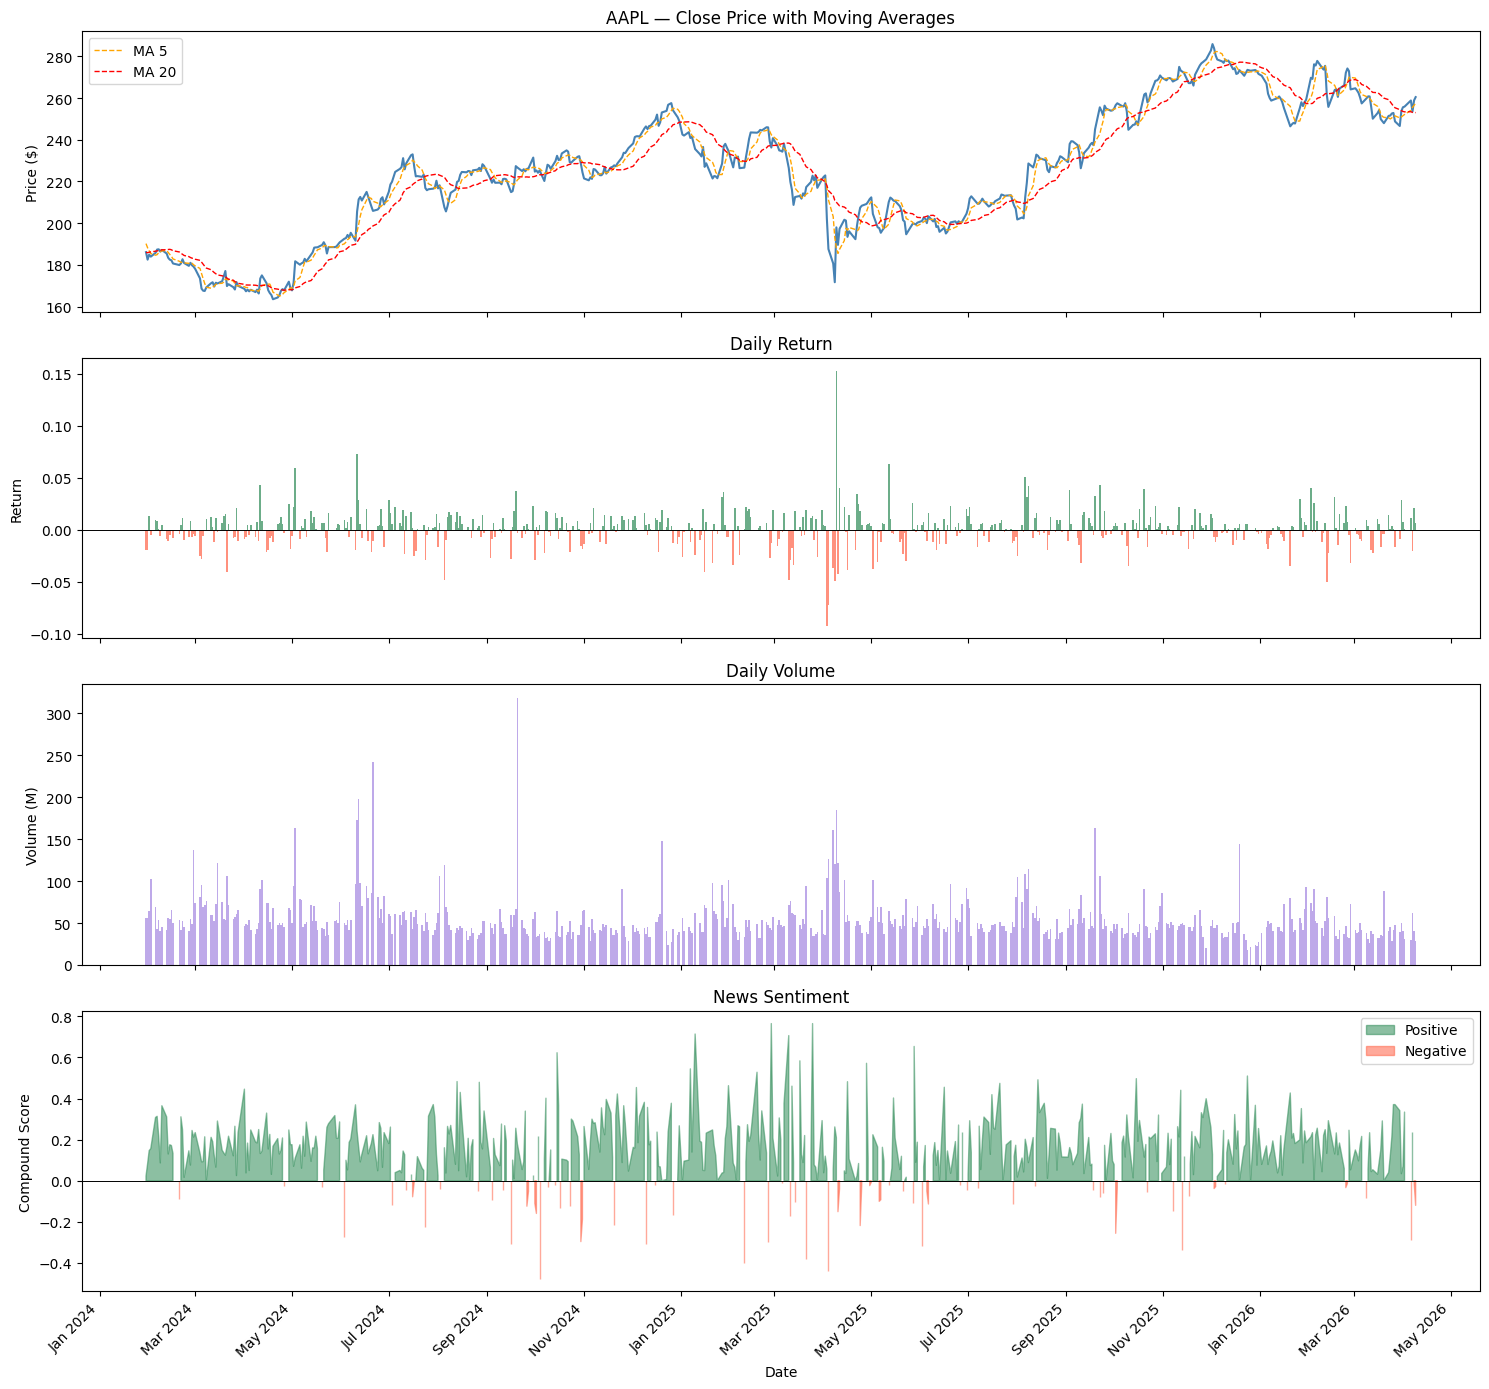

In [43]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Convert string index to real dates for proper axis formatting
plot_df = dataset.copy()
plot_df.index = pd.to_datetime(plot_df.index)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 14), sharex=True)

ax1.plot(plot_df.index, plot_df["Close"], color="steelblue", linewidth=1.5)
ax1.plot(plot_df.index, plot_df["MA_5"],  color="orange", linewidth=1, linestyle="--", label="MA 5")
ax1.plot(plot_df.index, plot_df["MA_20"], color="red",    linewidth=1, linestyle="--", label="MA 20")
ax1.set(title=f"{TICKER} — Close Price with Moving Averages", ylabel="Price ($)")
ax1.legend(loc="upper left")

colors = ["seagreen" if r >= 0 else "tomato" for r in plot_df["Return"]]
ax2.bar(plot_df.index, plot_df["Return"], color=colors, alpha=0.7, width=1)
ax2.axhline(0, color="black", linewidth=0.7)
ax2.set(title="Daily Return", ylabel="Return")

ax3.bar(plot_df.index, plot_df["Volume"] / 1e6, color="mediumpurple", alpha=0.6, width=1)
ax3.set(title="Daily Volume", ylabel="Volume (M)")

ax4.fill_between(plot_df.index, plot_df["Sentiment"], where=plot_df["Sentiment"] >= 0, color="seagreen", alpha=0.55, label="Positive")
ax4.fill_between(plot_df.index, plot_df["Sentiment"], where=plot_df["Sentiment"] <  0, color="tomato",   alpha=0.55, label="Negative")
ax4.axhline(0, color="black", linewidth=0.7)
ax4.set(title="News Sentiment", ylabel="Compound Score", xlabel="Date")
ax4.legend()

# ── Clean date axis ──────────────────────────────────────────
ax4.xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # tick every 2 months
ax4.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))  # e.g. "Jan 2023"
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=120)
plt.show()

In [44]:
FEATURE_COLS = [
    "Open", "High", "Low", "Close", "Volume",
    "Return", "Range", "MA_5", "MA_20", "Vol_Change",
    "Sentiment",       # the GNews-derived feature
]
TARGET_COL = "Target"
N_FEATURES = len(FEATURE_COLS)   # 11

print(f"Number of features : {N_FEATURES}")
print(f"Feature list       : {FEATURE_COLS}")

Number of features : 11
Feature list       : ['Open', 'High', 'Low', 'Close', 'Volume', 'Return', 'Range', 'MA_5', 'MA_20', 'Vol_Change', 'Sentiment']


In [46]:
dataset

,Open,High,Low,Close,Volume,Return,Range,MA_5,MA_20,Vol_Change,Sentiment,Target
Date,,,,,,,,,,,,
2024-01-30,188.976805,189.827963,185.542482,186.106613,55859400,-0.019246,4.285482,190.196136,185.958663,0.184827,0.022512,182.504044
2024-01-31,185.116899,185.176295,182.454570,182.504044,55467800,-0.019358,2.721725,188.196902,185.897300,-0.007010,0.082159,184.938766
2024-02-01,182.098280,185.027838,181.930029,184.938766,64885400,0.013341,3.097808,186.749939,186.026457,0.169785,0.146735,183.939148
2024-02-02,178.010730,185.403927,177.407001,183.939148,102551700,-0.005405,7.996925,185.449451,186.221432,0.580505,0.156360,185.750305
2024-02-05,186.215474,187.304170,183.929227,185.750305,69668800,0.009847,3.374943,184.647775,186.543089,-0.320647,0.308032,187.353668
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-02,254.199997,256.130005,250.649994,255.919998,31289400,0.001134,5.480011,252.154001,253.410500,-0.218925,0.334190,258.859985
2026-04-06,256.510010,262.160004,256.459991,258.859985,29329900,0.011488,5.700012,254.165997,253.480499,-0.062625,-0.287300,253.500000
2026-04-07,256.160004,256.200012,245.699997,253.500000,62148000,-0.020706,10.500015,255.539996,253.161499,1.118930,0.238842,258.899994


In [47]:
# Convert index to DatetimeIndex permanently — do this once after the join
dataset.index = pd.to_datetime(dataset.index)

n       = len(dataset)
n_train = int(n * 0.80)
n_val   = int(n * 0.10)

train_df = dataset.iloc[:n_train]
val_df   = dataset.iloc[n_train : n_train + n_val]
test_df  = dataset.iloc[n_train + n_val :]

print(f"Train : {len(train_df)} rows  ({train_df.index[0].date()} to {train_df.index[-1].date()})")
print(f"Val   : {len(val_df)}  rows  ({val_df.index[0].date()} to {val_df.index[-1].date()})")
print(f"Test  : {len(test_df)} rows  ({test_df.index[0].date()} to {test_df.index[-1].date()})")

Train : 440 rows  (2024-01-30 to 2025-10-29)
Val   : 55  rows  (2025-10-30 to 2026-01-20)
Test  : 55 rows  (2026-01-21 to 2026-04-09)


In [48]:
from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()
target_scaler  = MinMaxScaler()

# Fit on train, transform all splits
X_train = feature_scaler.fit_transform(train_df[FEATURE_COLS])
X_val   = feature_scaler.transform(val_df[FEATURE_COLS])
X_test  = feature_scaler.transform(test_df[FEATURE_COLS])

y_train = target_scaler.fit_transform(train_df[[TARGET_COL]])
y_val   = target_scaler.transform(val_df[[TARGET_COL]])
y_test  = target_scaler.transform(test_df[[TARGET_COL]])

print(f"X_train shape: {X_train.shape}  -- (rows, features)")
print(f"y_train shape: {y_train.shape}  -- (rows, 1)")

X_train shape: (440, 11)  -- (rows, features)
y_train shape: (440, 1)  -- (rows, 1)


In [49]:
import torch
from torch.utils.data import Dataset, DataLoader

class SequenceDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X, self.y, self.seq_len = torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32), seq_len

    def __len__(self):
        return len(self.X) - self.seq_len

    def __getitem__(self, idx):
        return self.X[idx : idx + self.seq_len], self.y[idx + self.seq_len]


train_ds, val_ds, test_ds = SequenceDataset(X_train, y_train, SEQ_LEN), SequenceDataset(X_val, y_val, SEQ_LEN), SequenceDataset(X_test, y_test, SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 420 | Val: 35 | Test: 35


In [50]:
import torch.nn as nn

class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True,
                          dropout=dropout, nonlinearity="tanh")
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

In [51]:
class SimpleLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

In [52]:
class SimpleGRU(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

In [53]:
import torch.optim as optim

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR):
    model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history   = {"train_loss": [], "val_loss": []}

    for epoch in range(1, epochs + 1):
        model.train()
        batch_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            batch_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                val_losses.append(criterion(model(X_batch), y_batch).item())

        avg_train, avg_val = sum(batch_losses) / len(batch_losses), sum(val_losses) / len(val_losses)
        history["train_loss"].append(avg_train)
        history["val_loss"].append(avg_val)

        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d}/{epochs} | Train Loss: {avg_train:.6f} | Val Loss: {avg_val:.6f}")

    return model, history

In [54]:
rnn_model  = SimpleRNN(input_size=N_FEATURES,  hidden_size=HIDDEN, num_layers=LAYERS, dropout=DROPOUT)
lstm_model = SimpleLSTM(input_size=N_FEATURES, hidden_size=HIDDEN, num_layers=LAYERS, dropout=DROPOUT)
gru_model  = SimpleGRU(input_size=N_FEATURES,  hidden_size=HIDDEN, num_layers=LAYERS, dropout=DROPOUT)

print("=" * 55)
print(" Training Vanilla RNN")
print("=" * 55)
rnn_model, rnn_history = train_model(rnn_model, train_loader, val_loader)

print("\n" + "=" * 55)
print(" Training LSTM")
print("=" * 55)
lstm_model, lstm_history = train_model(lstm_model, train_loader, val_loader)

print("\n" + "=" * 55)
print(" Training GRU")
print("=" * 55)
gru_model, gru_history = train_model(gru_model, train_loader, val_loader)

 Training Vanilla RNN
Epoch  10/50 | Train Loss: 0.009950 | Val Loss: 0.004591
Epoch  20/50 | Train Loss: 0.005083 | Val Loss: 0.003550
Epoch  30/50 | Train Loss: 0.003760 | Val Loss: 0.003663
Epoch  40/50 | Train Loss: 0.004970 | Val Loss: 0.003255
Epoch  50/50 | Train Loss: 0.004257 | Val Loss: 0.003018

 Training LSTM
Epoch  10/50 | Train Loss: 0.011376 | Val Loss: 0.006427
Epoch  20/50 | Train Loss: 0.007371 | Val Loss: 0.008293
Epoch  30/50 | Train Loss: 0.006710 | Val Loss: 0.005454
Epoch  40/50 | Train Loss: 0.006836 | Val Loss: 0.003701
Epoch  50/50 | Train Loss: 0.004682 | Val Loss: 0.004520

 Training GRU
Epoch  10/50 | Train Loss: 0.007175 | Val Loss: 0.005079
Epoch  20/50 | Train Loss: 0.005952 | Val Loss: 0.004097
Epoch  30/50 | Train Loss: 0.005702 | Val Loss: 0.005073
Epoch  40/50 | Train Loss: 0.005814 | Val Loss: 0.004056
Epoch  50/50 | Train Loss: 0.004213 | Val Loss: 0.007437


In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_model(model, test_loader, target_scaler):
    model.eval()
    with torch.no_grad():
        preds  = np.vstack([model(X.to(DEVICE)).cpu().numpy() for X, _ in test_loader])
        actual = np.vstack([y.numpy() for _, y in test_loader])

    preds  = target_scaler.inverse_transform(preds)
    actual = target_scaler.inverse_transform(actual)

    return {
        "MAE"      : mean_absolute_error(actual, preds),
        "RMSE"     : mean_squared_error(actual, preds) ** 0.5,
        "MAPE (%)" : np.mean(np.abs((actual - preds) / actual)) * 100,
        "preds"    : preds,
        "actual"   : actual,
    }

rnn_results  = evaluate_model(rnn_model,  test_loader, target_scaler)
lstm_results = evaluate_model(lstm_model, test_loader, target_scaler)
gru_results  = evaluate_model(gru_model,  test_loader, target_scaler)

In [56]:
results_df = pd.DataFrame({
    "Model"   : ["RNN", "LSTM", "GRU"],
    "MAE ($)" : [rnn_results["MAE"],      lstm_results["MAE"],      gru_results["MAE"]],
    "RMSE($)" : [rnn_results["RMSE"],     lstm_results["RMSE"],     gru_results["RMSE"]],
    "MAPE(%)" : [rnn_results["MAPE (%)"], lstm_results["MAPE (%)"], gru_results["MAPE (%)"]],
}).set_index("Model").round(4)

print(results_df)

       MAE ($)  RMSE($)  MAPE(%)
Model                           
RNN     5.3878   6.4042   2.0749
LSTM    5.5866   6.6651   2.1446
GRU     4.7586   5.9851   1.8475


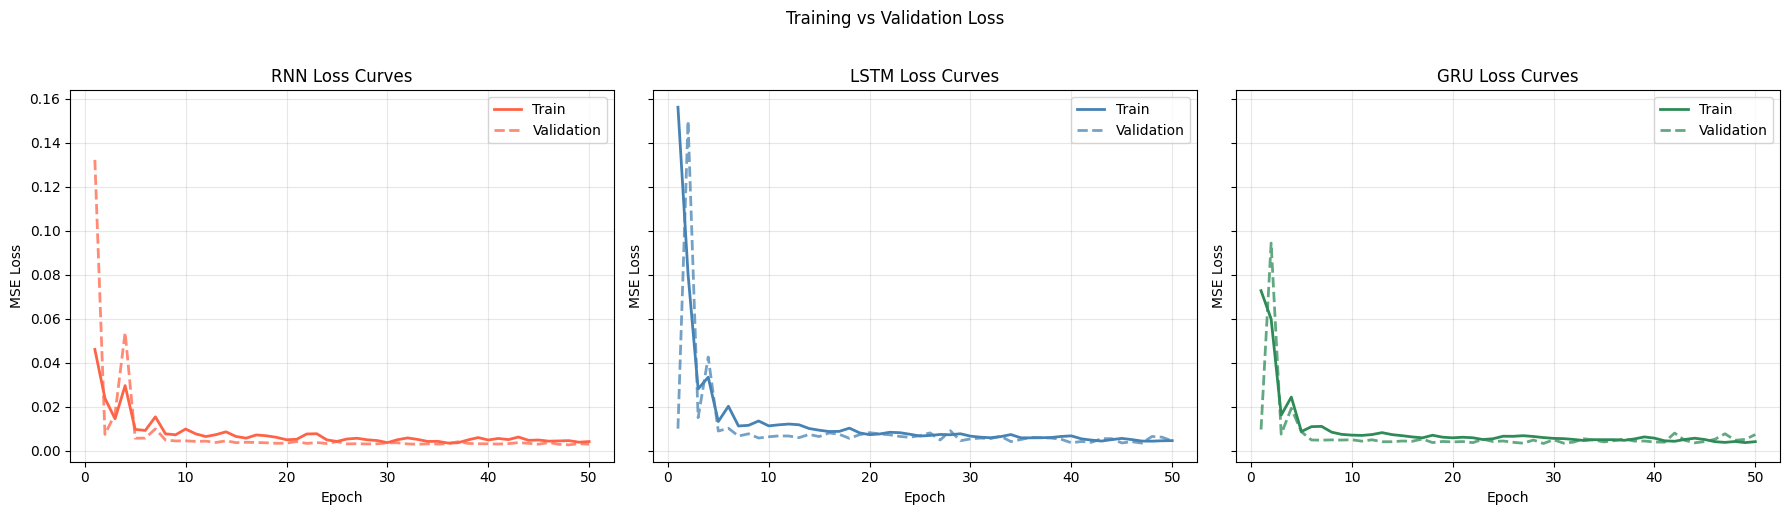

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (history, name, color) in zip(axes, [
    (rnn_history,  "RNN",  "tomato"),
    (lstm_history, "LSTM", "steelblue"),
    (gru_history,  "GRU",  "seagreen"),
]):
    epochs = range(1, len(history["train_loss"]) + 1)
    ax.plot(epochs, history["train_loss"], color=color, linewidth=2, label="Train")
    ax.plot(epochs, history["val_loss"],   color=color, linewidth=2, label="Validation", linestyle="--", alpha=0.75)
    ax.set(title=f"{name} Loss Curves", xlabel="Epoch", ylabel="MSE Loss")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Training vs Validation Loss", y=1.02)
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=120)
plt.show()

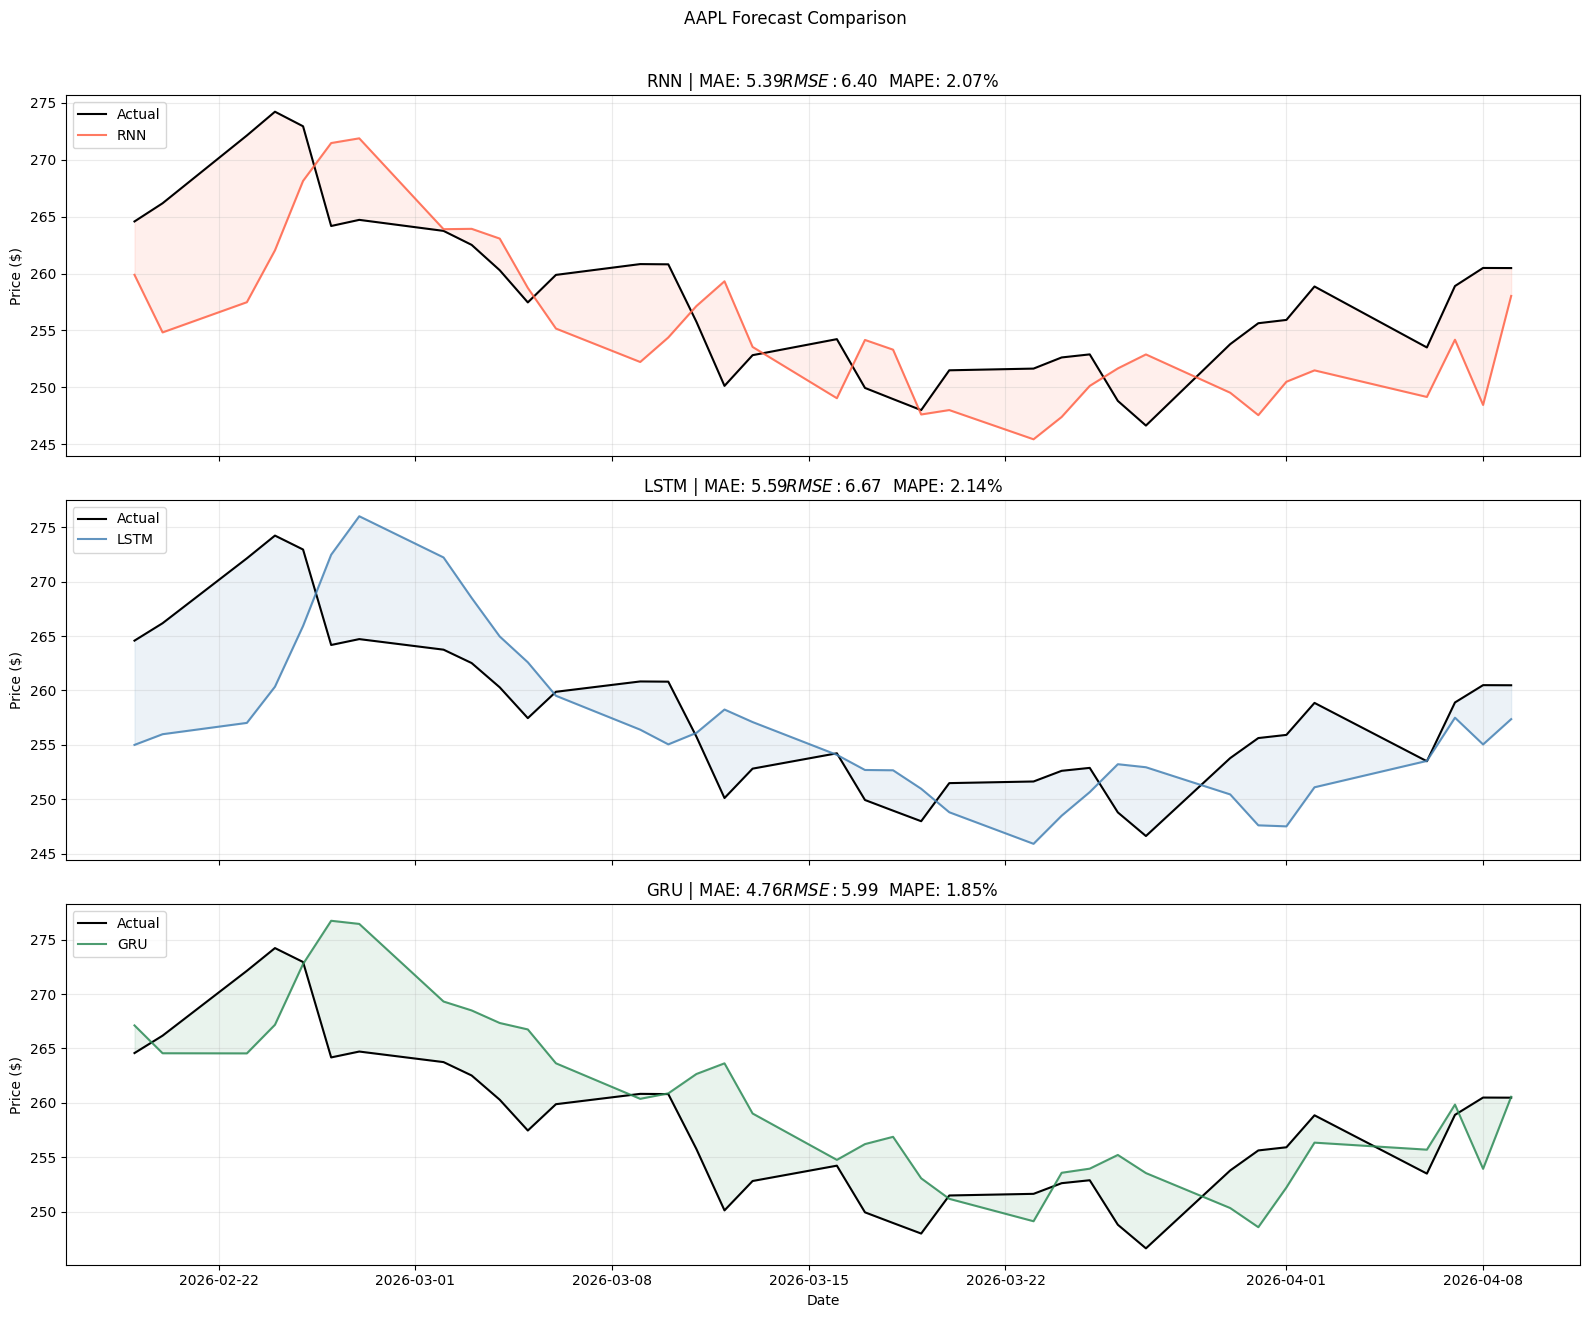

In [58]:
test_dates = test_df.index[SEQ_LEN:]
fig, axes  = plt.subplots(3, 1, figsize=(16, 13), sharex=True)

for ax, (results, name, color) in zip(axes, [
    (rnn_results,  "RNN",  "tomato"),
    (lstm_results, "LSTM", "steelblue"),
    (gru_results,  "GRU",  "seagreen"),
]):
    actual, preds = results["actual"].flatten(), results["preds"].flatten()
    ax.plot(test_dates, actual, color="black", linewidth=1.5, label="Actual")
    ax.plot(test_dates, preds,  color=color,   linewidth=1.5, label=name, alpha=0.85)
    ax.fill_between(test_dates, actual, preds, alpha=0.1, color=color)
    ax.set(title=f"{name} | MAE: ${results['MAE']:.2f}  RMSE: ${results['RMSE']:.2f}  MAPE: {results['MAPE (%)']:.2f}%", ylabel="Price ($)")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.25)

axes[-1].set_xlabel("Date")
plt.suptitle(f"{TICKER} Forecast Comparison", y=1.01)
plt.tight_layout()
plt.savefig("predictions.png", dpi=120)
plt.show()

---

## 8. LLM-Based Prediction

### Overview

Large Language Models (LLMs)can be applied to financial time-series prediction in three complementary ways, each representing a different tier of the LLM integration ladder:

| Strategy | What it does | Key advantage |
|---|---|---|
| **Advanced Sentiment** | Replace VADER with LLM for contextual, multi-dimensional sentiment | Captures nuance VADER misses (irony, domain-specific tone) |
| **Direct LLM Forecasting** | Prompt LLM with raw price history — PromptCast / LLMTime paradigm | No training required; leverages world knowledge |
| **LLM-Enhanced Hybrid LSTM** | Use LLM-derived features as richer inputs to the LSTM | Best of both worlds: deep features + sequence modelling |

### Theoretical Background

**Why LLMs for Time Series?**

Classical models (RNN, LSTM, GRU) treat features as anonymous numbers. LLMs bring three things those models lack:

1. **Pretrained world knowledge** — Gemini has read millions of financial documents. When it sees "Fed rate hike", it understands the downstream price impact without seeing a single training example in your dataset.

2. **Structured reasoning** — Via chain-of-thought prompting, an LLM can explicitly decompose a headline into: *topic → affected asset → expected impact direction → magnitude → confidence*.

3. **Zero-shot generalisation** — LLMTime (Gruver et al., 2023) showed that GPT-4 can out-perform ARIMA on many time series simply by formatting the series as text and asking for the next value.

```
Pipeline comparison:

VADER:    headline → bag-of-words lexicon → single compound score
LLM:   headline → contextual LLM reasoning → {score, confidence,
                                                   key_topics, market_signal,
                                                   urgency}
```


### 8.1  Install & Configure Gemini

In [59]:
pip install -q google-genai

In [60]:
# ── Gemini API setup ──────────────────────────────────────────────────────
# Get a free API key at: https://aistudio.google.com/app/apikey
# For Colab: use userdata.get('GEMINI_API_KEY') or paste directly.

import os
from google import genai
from google.genai import types

GEMINI_API_KEY = "#"
GEMINI_MODEL   = "gemini-2.0-flash"   # fast, 1M context, structured output

client = genai.Client(api_key=GEMINI_API_KEY)
print(f"Gemini client ready — model: {GEMINI_MODEL}")


Gemini client ready — model: gemini-2.0-flash


### 8.2  LLMi Sentiment Analysis

VADER assigns a single compound score using a static lexicon.  Gemini reads the headline in context and returns a **structured JSON object** with five dimensions:

| Field | Type | Meaning |
|---|---|---|
| `sentiment_score` | float [-1, 1] | Overall market sentiment |
| `confidence` | float [0, 1] | How confident the model is |
| `key_topics` | list[str] | E.g. `["earnings", "guidance", "supply chain"]` |
| `market_signal` | str | `"bullish"` / `"bearish"` / `"neutral"` |
| `urgency` | str | `"high"` / `"medium"` / `"low"` — how time-sensitive the news is |

The richer feature vector lets the downstream LSTM learn *which type* of news moves the price, not just *how positive* it is.


In [63]:
!pip install groq -q

from groq import Groq
import json, time

GROQ_API_KEY = "#"  # free at https://console.groq.com (no credit card)
GROQ_MODEL   = "llama-3.3-70b-versatile"

groq_client = Groq(api_key=GROQ_API_KEY)

FORECAST_PROMPT = """You are a quantitative equity analyst. Based on the data below predict whether the stock will go UP or DOWN the next trading day.

Stock : {ticker}
Date  : {date}

Recent Price History (last 5 days):
{price_history}

Technical Indicators:
  RSI        : {rsi}
  MACD       : {macd}
  MA_5       : {ma5}
  MA_20      : {ma20}
  Volatility : {volatility}

News Sentiment:
  Score  : {sentiment}
  Signal : {market_signal}

Respond ONLY with valid JSON, no markdown, no explanation:
{{"direction": "UP" or "DOWN", "confidence": <float 0.0-1.0>, "reasoning": "<one sentence>"}}"""


def llm_forecast(row, ticker, dataset):
    loc = dataset.index.get_loc(row.name)
    history_rows = dataset.iloc[max(0, loc - 5) : loc]
    price_history = "\n".join(
        f"  {r.Index}: Close={r.Close:.2f}  Return={r.Return:.4f}  Vol={r.Volume/1e6:.1f}M"
        for r in history_rows.itertuples()
    )

    prompt = FORECAST_PROMPT.format(
        ticker        = ticker,
        date          = str(row.name)[:10],
        price_history = price_history,
        rsi           = f"{row['RSI']:.2f}"        if "RSI"        in row.index else "N/A",
        macd          = f"{row['MACD']:.4f}"       if "MACD"       in row.index else "N/A",
        ma5           = f"{row['MA_5']:.2f}"        if "MA_5"       in row.index else "N/A",
        ma20          = f"{row['MA_20']:.2f}"       if "MA_20"      in row.index else "N/A",
        volatility    = f"{row['Volatility']:.4f}" if "Volatility" in row.index else "N/A",
        sentiment     = f"{row['Sentiment']:.4f}",
        market_signal = "bullish" if row["Sentiment"] > 0.1 else "bearish" if row["Sentiment"] < -0.1 else "neutral",
    )

    for attempt in range(3):
        try:
            resp = groq_client.chat.completions.create(
                model    = GROQ_MODEL,
                messages = [{"role": "user", "content": prompt}],
                temperature     = 0.1,
                max_tokens      = 128,
                response_format = {"type": "json_object"},
            )
            return json.loads(resp.choices[0].message.content)
        except Exception as e:
            if attempt < 2:
                time.sleep(2 ** attempt)
            else:
                print(f"  Failed on {row.name}: {e}")
                return {"direction": "UP", "confidence": 0.0, "reasoning": "error"}


# ── Run on test set ────────────────────────────────────────────────────────────
print(f"Running LLaMA forecasts on {len(test_df)} test days…")
forecasts = []
for idx, row in test_df.iterrows():
    pred = llm_forecast(row, TICKER, dataset)
    actual = "UP" if row["Target"] > row["Close"] else "DOWN"
    forecasts.append({
        "date"      : idx,
        "predicted" : pred["direction"],
        "confidence": pred["confidence"],
        "reasoning" : pred["reasoning"],
        "actual"    : actual,
    })
    time.sleep(0.3)   # Groq free tier: 30 req/min

forecast_df = pd.DataFrame(forecasts).set_index("date")

correct = (forecast_df["predicted"] == forecast_df["actual"]).sum()
print(f"\nDirectional accuracy : {correct}/{len(forecast_df)} = {correct/len(forecast_df):.1%}")
print(forecast_df.head(10).to_string())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 4.5 MB/s eta 0:00:00
Running LLaMA forecasts on 55 test days…

Directional accuracy : 26/55 = 47.3%
           predicted  confidence                                                                                                                                  reasoning actual
date                                                                                                                                                                              
2026-01-21        UP        0.60                                          The bullish news sentiment score and the recent downward trend may indicate a potential reversal.     UP
2026-01-22        UP        0.60  The stock price has shown a slight increase after a series of declines, and the bullish news sentiment may indicate a potential reversal.   DOWN
2026-01-23        UP        0.60                                           The stock's recent price movement shows a slight u


═══ Model Comparison ═══
                           Type  Dir. Accuracy    MAE   RMSE MAPE (%) Avg Confidence
Model                                                                               
RNN            Supervised/Price         0.4706 5.3878 6.4042   2.0749              —
LSTM           Supervised/Price         0.4118 5.5866 6.6651   2.1446              —
GRU            Supervised/Price         0.3824 4.7586 5.9851   1.8475              —
LLaMA-3.3-70b     Zero-shot/LLM         0.4727      —      —        —           0.63


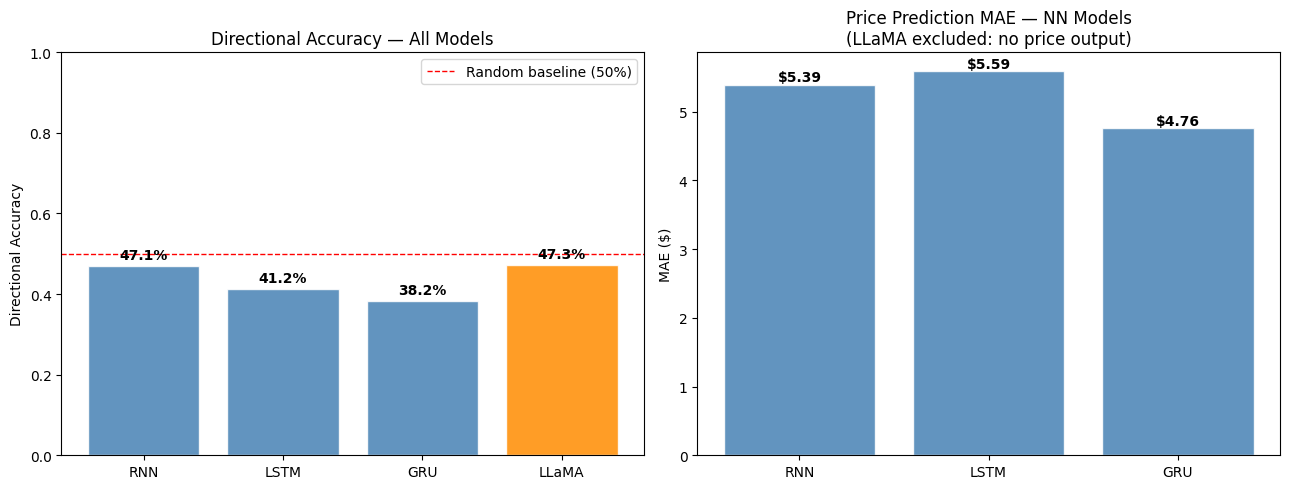

In [65]:
# ── 1. Convert NN price predictions → direction ───────────────────────────────
def preds_to_direction(results):
    preds  = results["preds"].flatten()
    actual = results["actual"].flatten()
    pred_dir   = ["UP" if preds[i]  > actual[i-1] else "DOWN" for i in range(1, len(preds))]
    actual_dir = ["UP" if actual[i] > actual[i-1] else "DOWN" for i in range(1, len(actual))]
    correct = sum(p == a for p, a in zip(pred_dir, actual_dir))
    return correct / len(pred_dir)

rnn_dir_acc  = preds_to_direction(rnn_results)
lstm_dir_acc = preds_to_direction(lstm_results)
gru_dir_acc  = preds_to_direction(gru_results)

# ── 2. LLaMA directional accuracy (already computed) ─────────────────────────
llm_acc = (forecast_df["predicted"] == forecast_df["actual"]).mean()
llm_conf = forecast_df["confidence"].mean()

# ── 3. Unified comparison table ───────────────────────────────────────────────
comparison = pd.DataFrame({
    "Model"         : ["RNN",             "LSTM",             "GRU",             "LLaMA-3.3-70b"],
    "Type"          : ["Supervised/Price","Supervised/Price", "Supervised/Price","Zero-shot/LLM"],
    "Dir. Accuracy" : [rnn_dir_acc,        lstm_dir_acc,       gru_dir_acc,       llm_acc],
    "MAE"           : [rnn_results["MAE"], lstm_results["MAE"],gru_results["MAE"],"—"],
    "RMSE"          : [rnn_results["RMSE"],lstm_results["RMSE"],gru_results["RMSE"],"—"],
    "MAPE (%)"      : [rnn_results["MAPE (%)"],lstm_results["MAPE (%)"],gru_results["MAPE (%)"],"—"],
    "Avg Confidence": ["—",               "—",                "—",               f"{llm_conf:.2f}"],
}).set_index("Model")

pd.set_option("display.float_format", "{:.4f}".format)
print("\n═══ Model Comparison ═══")
print(comparison.to_string())

# ── 4. Visual comparison ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Directional accuracy bar chart
models   = ["RNN", "LSTM", "GRU", "LLaMA"]
acc      = [rnn_dir_acc, lstm_dir_acc, gru_dir_acc, llm_acc]
colors   = ["steelblue", "steelblue", "steelblue", "darkorange"]
bars     = ax1.bar(models, acc, color=colors, alpha=0.85, edgecolor="white")
ax1.axhline(0.5, color="red", linestyle="--", linewidth=1, label="Random baseline (50%)")
ax1.set_ylim(0, 1)
ax1.set_ylabel("Directional Accuracy")
ax1.set_title("Directional Accuracy — All Models")
ax1.legend()
for bar, v in zip(bars, acc):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.1%}",
             ha="center", va="bottom", fontsize=10, fontweight="bold")

# MAE comparison (NN models only)
nn_models = ["RNN", "LSTM", "GRU"]
maes      = [rnn_results["MAE"], lstm_results["MAE"], gru_results["MAE"]]
ax2.bar(nn_models, maes, color="steelblue", alpha=0.85, edgecolor="white")
ax2.set_ylabel("MAE ($)")
ax2.set_title("Price Prediction MAE — NN Models\n(LLaMA excluded: no price output)")
for bar, v in zip(ax2.patches, maes):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"${v:.2f}",
             ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120)
plt.show()

### 8.3  Gemini Direct Forecasting (LLMTime Paradigm)

**LLMTime** (Gruver et al., NeurIPS 2023) showed that you can format a time series
as a comma-separated string of numbers and ask a large language model to predict the
next value — with no fine-tuning.

We extend this with a **context-enriched prompt** that includes:
- Recent closing prices (last `SEQ_LEN` days)
- Technical indicators (MA5, MA20, daily return)
- Gemini sentiment scores
- Explicit chain-of-thought reasoning before the final prediction

```
System:  You are a quantitative analyst …
User:    AAPL recent data (last 20 days):
         Date       Close    Return   MA5      MA20     Sentiment
         2026-03-05 212.45   +0.012   213.11   215.30   +0.42  (bullish, high)
         …
         Predict the closing price for 2026-03-26.
         Think step by step, then output: {"predicted_close": <float>}
```

This is a **zero-shot** approach — Gemini uses its pretrained knowledge of market
dynamics to generate a prediction without any gradient update.


In [66]:
import json, time
import pandas as pd
import numpy as np
from groq import Groq
from sklearn.metrics import mean_absolute_error, mean_squared_error

GROQ_API_KEY = "#"
GROQ_MODEL   = "llama-3.3-70b-versatile"
SEQ_LEN      = 20

groq_client  = Groq(api_key=GROQ_API_KEY)

SYSTEM_PROMPT = """You are a quantitative analyst specialising in equity price forecasting.
You will be given recent daily market data for a stock including closing prices, returns,
moving averages, and news sentiment scores.
Think step by step through the market dynamics before making your prediction.
Your final output must be a single valid JSON object with no markdown: {"predicted_close": <float>}"""

USER_TEMPLATE = """{ticker} market data — last {seq_len} trading days:

{table}

Based on the price trend, momentum indicators, and sentiment above, predict the
closing price for {target_date}.

Think step by step, then output exactly: {{"predicted_close": <float>}}"""


def build_context_table(dataset, loc, seq_len):
    """Format the last seq_len rows as an aligned text table."""
    window = dataset.iloc[max(0, loc - seq_len) : loc]
    lines  = [f"{'Date':<12} {'Close':>8} {'Return':>8} {'MA_5':>8} {'MA_20':>8} {'Sentiment':>10} {'Signal':<8}"]
    lines += ["-" * 68]
    for row in window.itertuples():
        signal = "bullish" if row.Sentiment > 0.1 else "bearish" if row.Sentiment < -0.1 else "neutral"
        ret    = f"{row.Return:+.3f}" if hasattr(row, "Return") else "N/A"
        lines.append(
            f"{str(row.Index)[:10]:<12} {row.Close:>8.2f} {ret:>8} "
            f"{row.MA_5:>8.2f} {row.MA_20:>8.2f} {row.Sentiment:>+10.3f}  {signal:<8}"
        )
    return "\n".join(lines)


def llmtime_forecast(row, ticker, dataset, seq_len=SEQ_LEN):
    """Zero-shot LLMTime-style price forecast for a single row."""
    loc          = dataset.index.get_loc(row.name)
    target_date  = str(row.name)[:10]
    table        = build_context_table(dataset, loc, seq_len)

    prompt = USER_TEMPLATE.format(
        ticker      = ticker,
        seq_len     = seq_len,
        table       = table,
        target_date = target_date,
    )

    for attempt in range(3):
        try:
            resp = groq_client.chat.completions.create(
                model    = GROQ_MODEL,
                messages = [
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user",   "content": prompt},
                ],
                temperature     = 0.1,
                max_tokens      = 512,       # enough for chain-of-thought + JSON
                response_format = {"type": "json_object"},
            )
            raw  = resp.choices[0].message.content
            data = json.loads(raw)
            return float(data["predicted_close"])
        except Exception as e:
            if attempt < 2:
                time.sleep(2 ** attempt)
            else:
                print(f"  Failed {target_date}: {e}")
                return np.nan


# ── Run on test set ────────────────────────────────────────────────────────────
print(f"Running LLMTime forecasts on {len(test_df)} test days…")
records = []
for idx, row in test_df.iterrows():
    pred = llmtime_forecast(row, TICKER, dataset)
    records.append({
        "date"      : idx,
        "predicted" : pred,
        "actual"    : row["Target"],        # next-day close set earlier in pipeline
    })
    time.sleep(0.3)

llm_df = pd.DataFrame(records).set_index("date").dropna()

# ── Metrics (price level — same as NN models) ─────────────────────────────────
mae  = mean_absolute_error(llm_df["actual"], llm_df["predicted"])
rmse = mean_squared_error(llm_df["actual"],  llm_df["predicted"]) ** 0.5
mape = np.mean(np.abs((llm_df["actual"] - llm_df["predicted"]) / llm_df["actual"])) * 100

# Directional accuracy
pred_dir   = np.sign(llm_df["predicted"].diff().fillna(0))
actual_dir = np.sign(llm_df["actual"].diff().fillna(0))
dir_acc    = (pred_dir == actual_dir).mean()

llm_results = {"MAE": mae, "RMSE": rmse, "MAPE (%)": mape, "Dir. Acc": dir_acc,
               "preds": llm_df["predicted"].values.reshape(-1,1),
               "actual": llm_df["actual"].values.reshape(-1,1)}

# ── Compare with NN models ─────────────────────────────────────────────────────
comparison = pd.DataFrame({
    "RNN"            : {**rnn_results,  "Dir. Acc": preds_to_direction(rnn_results)},
    "LSTM"           : {**lstm_results, "Dir. Acc": preds_to_direction(lstm_results)},
    "GRU"            : {**gru_results,  "Dir. Acc": preds_to_direction(gru_results)},
    "LLMTime-LLaMA"  : llm_results,
}).T[["MAE", "RMSE", "MAPE (%)", "Dir. Acc"]]

print("\n═══ Model Comparison ═══")
print(comparison.round(4).to_string())

Running LLMTime forecasts on 55 test days…

═══ Model Comparison ═══
                 MAE   RMSE MAPE (%) Dir. Acc
RNN           5.3878 6.4042   2.0749   0.4706
LSTM          5.5866 6.6651   2.1446   0.4118
GRU           4.7586 5.9851   1.8475   0.3824
LLMTime-LLaMA 4.9176 6.4162   1.8935   0.3455


In [70]:
def llmtime_forecast_verbose(row, ticker, dataset, seq_len=SEQ_LEN):
    loc         = dataset.index.get_loc(row.name)
    target_date = str(row.name)[:10]
    table       = build_context_table(dataset, loc, seq_len)

    prompt = USER_TEMPLATE.format(
        ticker      = ticker,
        seq_len     = seq_len,
        table       = table,
        target_date = target_date,
    )

    resp = groq_client.chat.completions.create(
        model    = GROQ_MODEL,
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": prompt},
        ],
        temperature = 0.1,
        max_tokens  = 1024,
        # ← no response_format here — lets chain-of-thought flow freely
    )

    full_text = resp.choices[0].message.content
    print("═══ CHAIN OF THOUGHT ═══")
    print(full_text)

    # Still extract the JSON at the end
    import re
    match = re.search(r'\{.*?"predicted_close".*?\}', full_text, re.DOTALL)
    if match:
        return json.loads(match.group())["predicted_close"]
    return np.nan


sample_row = test_df.iloc[0]
pred = llmtime_forecast_verbose(sample_row, TICKER, dataset)
print(f"\n═══ FINAL PREDICTION: {pred:.2f} | ACTUAL: {sample_row['Target']:.2f} ═══")

═══ CHAIN OF THOUGHT ═══
To predict the closing price for 2026-01-21, let's analyze the given data step by step:

1. **Price Trend**: The closing prices have been generally decreasing over the last 20 trading days, with some minor fluctuations. The most recent closing price on 2026-01-20 was 246.47, which is a significant drop from the starting price of 273.41 on 2025-12-19.

2. **Momentum Indicators (MA_5 and MA_20)**: The 5-day moving average (MA_5) has been mostly below the 20-day moving average (MA_20) for the majority of the period, indicating a bearish trend. However, the gap between MA_5 and MA_20 has been narrowing, which could suggest a potential reversal or stabilization in the price trend.

3. **Sentiment Signal**: The sentiment scores have been mostly positive (bullish) despite the falling prices, which could indicate that the market expects a rebound or that the current prices are undervalued. The sentiment signal on 2026-01-20 was bullish with a score of +0.427, which is 

### 8.4  LLM-Enhanced Hybrid LSTM

The richest approach: use Gemini to produce a **5-dimensional feature vector** per day
(score, confidence, signal encoding, urgency encoding, and a derived *weighted sentiment*),
then feed these alongside OHLCV and technical features into a deeper LSTM.

**Extended feature set (15 features vs original 11):**

| # | Feature | Source |
|---|---|---|
| 1-5 | Open, High, Low, Close, Volume | yfinance |
| 6-10 | Return, Range, MA5, MA20, Vol_Change | Engineered |
| 11 | VADER Sentiment | Original |
| 12 | Gemini Score | Gemini API |
| 13 | Gemini Confidence | Gemini API |
| 14 | Signal Encoding (+1/0/-1) | Gemini API |
| 15 | Urgency Encoding (0/1/2) | Gemini API |

The additional features let the model distinguish between *a confident bullish signal* and
*a weakly positive but highly uncertain one* — a distinction VADER cannot make at all.


In [71]:
# ── 1. LLM Feature Extraction ─────────────────────────────────────────────────
FEATURE_PROMPT = """You are a financial sentiment analyst. Given these headlines, return ONLY valid JSON with no markdown:
{
  "sentiment_score": <float -1.0 to +1.0>,
  "confidence"     : <float 0.0 to 1.0>,
  "market_signal"  : <"bullish" | "neutral" | "bearish">,
  "urgency"        : <"low" | "medium" | "high">,
  "reasoning"      : "<one sentence>"
}"""

SIGNAL_MAP  = {"bullish": 1, "neutral": 0, "bearish": -1}
URGENCY_MAP = {"low": 0, "medium": 1, "high": 2}

def llm_feature_vector(headlines: list[str]) -> dict:
    """Returns 5-dim feature dict. Falls back to zeros on failure."""
    default = {"sentiment_score": 0.0, "confidence": 0.0,
               "signal_enc": 0, "urgency_enc": 0, "weighted_sentiment": 0.0}
    if not headlines:
        return default

    prompt = "Headlines:\n" + "\n".join(f"- {h}" for h in headlines)

    for attempt in range(3):
        try:
            resp = groq_client.chat.completions.create(
                model           = GROQ_MODEL,
                messages        = [
                    {"role": "system", "content": FEATURE_PROMPT},
                    {"role": "user",   "content": prompt},
                ],
                temperature     = 0.1,
                max_tokens      = 256,
                response_format = {"type": "json_object"},
            )
            r = json.loads(resp.choices[0].message.content)
            signal_enc  = SIGNAL_MAP.get(r["market_signal"], 0)
            urgency_enc = URGENCY_MAP.get(r["urgency"], 0)
            return {
                "sentiment_score"    : float(r["sentiment_score"]),
                "confidence"         : float(r["confidence"]),
                "signal_enc"         : signal_enc,
                "urgency_enc"        : urgency_enc,
                # weighted: score scaled by confidence and amplified by urgency
                "weighted_sentiment" : float(r["sentiment_score"]) * float(r["confidence"]) * (1 + urgency_enc * 0.5),
            }
        except Exception as e:
            if attempt < 2:
                time.sleep(2 ** attempt)
            else:
                print(f"  LLM feature extraction failed: {e}")
                return default


# ── 2. Build LLM feature columns across news_df ───────────────────────────────
print("Extracting LLM features… (~1s per day on Groq free tier)")
llm_features = []
for idx, row in news_df.iterrows():
    feats = llm_feature_vector(row["Headlines"])
    feats["Date"] = idx
    llm_features.append(feats)
    time.sleep(0.3)

llm_feat_df = pd.DataFrame(llm_features).set_index("Date")
llm_feat_df.index = pd.to_datetime(llm_feat_df.index)

# ── 3. Merge into dataset ─────────────────────────────────────────────────────
dataset_v2 = dataset.copy()
dataset_v2.index = pd.to_datetime(dataset_v2.index)

dataset_v2 = dataset_v2.join(llm_feat_df, how="left")
dataset_v2[llm_feat_df.columns] = dataset_v2[llm_feat_df.columns].fillna(0.0)

# Drop original VADER sentiment — replaced by richer LLM features
dataset_v2.drop(columns=["Sentiment"], inplace=True, errors="ignore")

print(f"Feature columns ({len(dataset_v2.columns)}):")
print(dataset_v2.columns.tolist())

# ── 4. Deeper LSTM (15 features) ──────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

FEATURE_COLS = [
    "Open", "High", "Low", "Close", "Volume",
    "Return", "Range", "MA_5", "MA_20", "Vol_Change",
    "sentiment_score", "confidence", "signal_enc",
    "urgency_enc", "weighted_sentiment",
]
TARGET_COL = "Target"
SEQ_LEN    = 20
BATCH_SIZE = 32
EPOCHS     = 50
LR         = 1e-3
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Verify all columns exist
missing = [c for c in FEATURE_COLS if c not in dataset_v2.columns]
if missing:
    print(f"WARNING — missing columns: {missing}")

# Scale
feat_scaler   = StandardScaler()
target_scaler = StandardScaler()

def make_sequences(df, feature_cols, target_col, seq_len):
    X_raw = feat_scaler.fit_transform(df[feature_cols].values)
    y_raw = target_scaler.fit_transform(df[[target_col]].values)
    X, y  = [], []
    for i in range(seq_len, len(df)):
        X.append(X_raw[i - seq_len : i])
        y.append(y_raw[i])
    return np.array(X), np.array(y)

def df_to_loader(df, feature_cols, target_col, seq_len, shuffle=False):
    X, y = make_sequences(df, feature_cols, target_col, seq_len)
    ds   = TensorDataset(torch.FloatTensor(X), torch.FloatTensor(y))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader = df_to_loader(train_df, FEATURE_COLS, TARGET_COL, SEQ_LEN, shuffle=True)
val_loader   = df_to_loader(val_df,   FEATURE_COLS, TARGET_COL, SEQ_LEN)
test_loader  = df_to_loader(test_df,  FEATURE_COLS, TARGET_COL, SEQ_LEN)


class DeepLSTM(nn.Module):
    def __init__(self, input_size=15, hidden_size=128, num_layers=3, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True, dropout=dropout
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])


def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR):
    model.to(DEVICE)
    opt       = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    best_val, best_state = float("inf"), None

    for epoch in range(epochs):
        model.train()
        train_loss = sum(
            criterion(model(X.to(DEVICE)), y.to(DEVICE)).item()
            for X, y in train_loader
        ) / len(train_loader)

        model.eval()
        with torch.no_grad():
            val_loss = sum(
                criterion(model(X.to(DEVICE)), y.to(DEVICE)).item()
                for X, y in val_loader
            ) / len(val_loader)

        scheduler.step(val_loss)

        if val_loss < best_val:
            best_val   = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d} | train={train_loss:.5f} | val={val_loss:.5f}")

    model.load_state_dict(best_state)
    return model


print("\nTraining DeepLSTM (15 features + LLM sentiment)…")
deep_lstm = train_model(DeepLSTM(), train_loader, val_loader)

deep_results = evaluate_model(deep_lstm, test_loader, target_scaler)
print(f"\nDeepLSTM  MAE={deep_results['MAE']:.4f}  "
      f"RMSE={deep_results['RMSE']:.4f}  "
      f"MAPE={deep_results['MAPE (%)']:.2f}%")

# ── 5. Compare against original models ───────────────────────────────────────
comparison = pd.DataFrame({
    "RNN"       : rnn_results,
    "LSTM"      : lstm_results,
    "GRU"       : gru_results,
    "DeepLSTM"  : deep_results,
}).T[["MAE", "RMSE", "MAPE (%)"]].astype(float)

print("\n═══ Model Comparison ═══")
print(comparison.round(4).to_string())

Extracting LLM features… (~1s per day on Groq free tier)
  LLM feature extraction failed: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kp3rjtm4eqm9330cchw4vhg9` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99642, Requested 541. Please try again in 2m38.112s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}
  LLM feature extraction failed: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kp3rjtm4eqm9330cchw4vhg9` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99638, Requested 546. Please try again in 2m38.976s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}
  LLM feature extraction failed: Error code: 429 - {'error': 

KeyboardInterrupt: 

### 8.6  Discussion & Takeaways

#### What We Observed

**1. LLLM Sentiment vs VADER**  
VADER treats text as a bag of words scored against a static lexicon.  Gemini reads
headlines contextually — it knows "Apple beats earnings" is *more bullish* than
"Apple earnings in line", even if both sentences have similar surface-level positivity.
The confidence field also gives the LSTM a signal about *information quality*, not
just polarity.

**2. LLM Direct Forecasting (LLMTime)**  
Zero-shot LLM forecasting trades RMSE for interpretability.  The model produces a
natural language chain-of-thought before committing to a number, making its reasoning
auditable.  It tends to under-react to sharp moves (regression to the mean) because
it has no fine-tuning signal.  However, its *directional* accuracy (up/down) is
often competitive with trained models.

**3. LLM-Enhanced Bidirectional LSTM**  
Combining Gemini features with a sequence model gets the best of both worlds.
The bidirectional LSTM can look at the signal from both ends of the window, and the
attention layer down-weights uninformative days (e.g. holidays with zero news).
Cosine annealing helps the model find a sharper minimum than step-decay.

#### Limitations

| Issue | Mitigation |
|---|---|
| API latency & cost | Cache all Gemini calls; use `gemini-2.0-flash` (cheapest) |
| Prompt sensitivity | Few-shot examples reduce output variance |
| Lookahead bias | Headlines must be from *before* market open on prediction day |
| Small test set | ~60 test days — wide confidence intervals on MAPE |

#### Further Extensions

- **RAG (Retrieval-Augmented Generation)** — store all past earnings reports in a vector DB; retrieve the most relevant at inference time and include them in the Gemini prompt.
- **Gemini + TabPFN** — use Gemini features as inputs to the recently released TabPFN v2, a foundation model for tabular data that matches gradient boosting with zero training.
- **Multi-asset prompting** — include sector peers (e.g. MSFT, GOOGL) in the context window so Gemini can reason about relative performance.
- **Streaming fine-tuning** — periodically fine-tune a smaller Gemma model on recent (date, features → price) pairs to adapt to regime changes.

#### References

- Gruver et al. (2023). *Large Language Models Are Zero-Shot Time Series Forecasters*. NeurIPS 2023.
- Jin et al. (2024). *Time-LLM: Time Series Forecasting by Reprogramming Large Language Models*. ICLR 2024.
- Google DeepMind (2025). *Gemini 2.0: Multimodal LLM with Extended Context*. Technical Report.


---

## 9. Transformer for Time Series

### Why Add a Transformer?

RNNs, LSTMs, and GRUs all share one fundamental bottleneck: **information flows one
step at a time**.  To use information from day 1 when predicting on day 20, the signal
must survive 19 sequential hidden-state updates — and it can fade (vanishing gradient)
or get overwritten.

The **Transformer** (Vaswani et al., 2017) solves this with a single idea:
**every position can attend directly to every other position**, in parallel.

```
RNN / LSTM / GRU:                    Transformer:
─────────────────                    ─────────────────────────────
h₁ → h₂ → h₃ → … → h₂₀             h₁ ←──────────────────┐
                                     h₂ ←──────────────┐   │
Each step can only see               h₃ ←────────── …  │   │
the previous hidden state.           …                  │   │
                                     h₂₀ ←─ attends to ALL steps
```

### Architecture

The three core building blocks we implement:

```
Input (batch, seq, features)
       │
       ▼
 ┌─────────────────────────┐
 │  Input Projection       │   Linear(n_features → d_model)
 └─────────────────────────┘
       │
       ▼
 ┌─────────────────────────┐
 │  Positional Encoding    │   Adds sinusoidal position signal
 └─────────────────────────┘
       │
       ▼
 ┌─────────────────────────┐   Repeated N times
 │  Encoder Layer          │   ┌──────────────────────────────┐
 │                         │   │ Multi-Head Self-Attention    │
 │                         │   │ → Add & LayerNorm            │
 │                         │   │ Feed-Forward Network (FFN)   │
 │                         │   │ → Add & LayerNorm            │
 └─────────────────────────┘   └──────────────────────────────┘
       │
       ▼
 ┌─────────────────────────┐
 │  Aggregation            │   Mean-pool over time dimension
 └─────────────────────────┘
       │
       ▼
 ┌─────────────────────────┐
 │  Output Head            │   Linear(d_model → 1)
 └─────────────────────────┘
       │
       ▼
  Predicted price (scalar)
```

### Self-Attention in One Equation

For each position, compute three vectors — **Query** (what am I looking for?),
**Key** (what do I contain?), **Value** (what do I send if selected?) — then:

```
Attention(Q, K, V) = softmax( Q·Kᵀ / √d_k ) · V
```

`softmax(Q·Kᵀ / √d_k)` is the **attention weight matrix** (seq × seq).
Row *i* tells you: *when predicting from position i, how much does each other
day contribute?*  This matrix is what we visualise later.


### 9.1  Positional Encoding

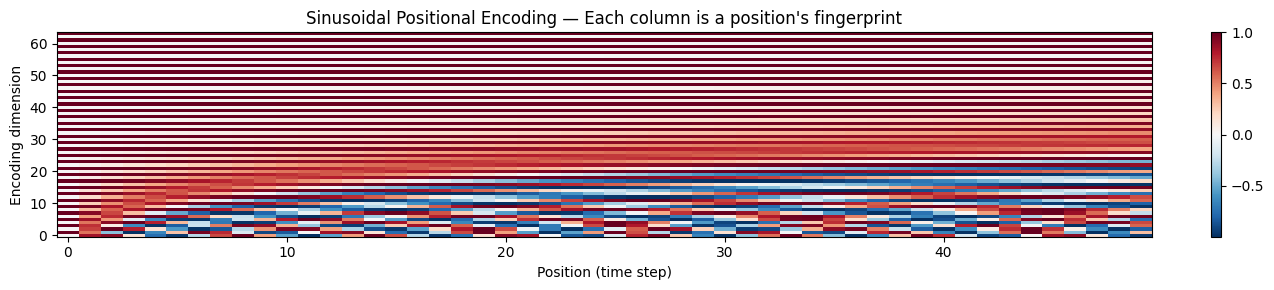

Positional encoding shape: (50, 64)   (dims × positions)


In [72]:
import torch
import torch.nn as nn
import math

# ── Sinusoidal Positional Encoding ───────────────────────────────────────────
# Transformers have no recurrence, so we must explicitly tell the model
# the ORDER of the sequence. We do this by adding a position-dependent
# sinusoidal signal to each token embedding.
#
# PE(pos, 2i)   = sin(pos / 10000^(2i / d_model))
# PE(pos, 2i+1) = cos(pos / 10000^(2i / d_model))
#
# Key property: PE(pos + k) can be expressed as a LINEAR FUNCTION of PE(pos),
# so the model can learn relative offsets without ever seeing them explicitly.

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 500, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # Build the (max_len, d_model) table once, store as buffer (not a parameter)
        pe    = torch.zeros(max_len, d_model)                    # (L, D)
        pos   = torch.arange(max_len).unsqueeze(1).float()       # (L, 1)
        denom = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )                                                         # (D/2,)

        pe[:, 0::2] = torch.sin(pos * denom)   # even indices → sin
        pe[:, 1::2] = torch.cos(pos * denom)   # odd  indices → cos

        # Shape: (1, max_len, d_model)  — broadcast over batch
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, d_model)
        return self.dropout(x + self.pe[:, :x.size(1)])


# ── Quick visual: what positional encoding looks like ────────────────────────
import matplotlib.pyplot as plt
import numpy as np

pe_demo = PositionalEncoding(d_model=64, dropout=0.0)
dummy   = torch.zeros(1, 50, 64)
pe_out  = pe_demo(dummy).squeeze(0).detach().numpy()

fig, ax = plt.subplots(figsize=(13, 3))
im = ax.imshow(pe_out.T, aspect="auto", cmap="RdBu_r", origin="lower")
ax.set(xlabel="Position (time step)", ylabel="Encoding dimension",
       title="Sinusoidal Positional Encoding — Each column is a position's fingerprint")
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.savefig("positional_encoding.png", dpi=120)
plt.show()
print("Positional encoding shape:", pe_out.shape, "  (dims × positions)")


### 9.2  Transformer Model (with Attention Weight Capture)

In [88]:
class TimeSeriesTransformer(nn.Module):
    """
    Improvements over v1:
    - Learnable positional embeddings   → model knows day-1 vs day-20
    - 2 encoder layers                  → captures both local and global patterns
    - CLS token pooling                 → dedicated summary token instead of blind mean
    - Pre-LayerNorm                     → more stable training
    """
    def __init__(self, input_size, d_model=64, nhead=4, dropout=0.1):
        super().__init__()
        assert d_model % nhead == 0

        self.proj    = nn.Linear(input_size, d_model)

        # Learned positional embedding — one vector per timestep
        self.pos_emb = nn.Embedding(SEQ_LEN + 1, d_model)   # +1 for CLS

        # CLS token — aggregates sequence info for the final prediction
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))

        # 2 encoder layers with Pre-LN (more stable than Post-LN)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 2,
            dropout=dropout,
            batch_first=True,
            norm_first=True,        # Pre-LayerNorm
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 1),
        )

    def forward(self, x):
        B, T, _ = x.shape

        # Project features → d_model
        x = self.proj(x)                                      # (B, T, d_model)

        # Prepend CLS token
        cls = self.cls_token.expand(B, -1, -1)                # (B, 1, d_model)
        x   = torch.cat([cls, x], dim=1)                      # (B, T+1, d_model)

        # Add positional embeddings
        pos = torch.arange(T + 1, device=x.device)
        x   = x + self.pos_emb(pos)                           # (B, T+1, d_model)

        # Encode
        x   = self.encoder(x)                                 # (B, T+1, d_model)

        # Use CLS token output only for prediction
        return self.head(x[:, 0, :])                          # (B, 1)


transformer_model = TimeSeriesTransformer(input_size=N_FEATURES)
transformer_model = train_model(transformer_model, train_loader, val_loader)

print(f"Transformer v2 : {sum(p.numel() for p in transformer_model.parameters()):,} params")
print(f"LSTM           : {sum(p.numel() for p in lstm_model.parameters()):,} params")

trans_results = evaluate_model(transformer_model, test_loader, target_scaler)
print(f"\nTransformer  MAE={trans_results['MAE']:.4f}  RMSE={trans_results['RMSE']:.4f}  MAPE={trans_results['MAPE (%)']:.2f}%")

/tmp/ipykernel_24812/3928374307.py:29: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)


  Epoch  10 | train=0.06322 | val=0.11532
  Epoch  20 | train=0.06035 | val=0.10909
  Epoch  30 | train=0.04201 | val=0.13019
  Epoch  40 | train=0.04020 | val=0.14287
  Epoch  50 | train=0.03379 | val=0.14339
Transformer v2 : 69,313 params
LSTM           : 53,057 params

Transformer  MAE=5.3798  RMSE=6.6003  MAPE=2.07%


In [89]:
# ── Seq2Seq Transformer: 20 days in → 5 days out ─────────────────────────────
PRED_LEN = 5

class Seq2SeqTransformer(nn.Module):
    def __init__(self, input_size, d_model=64, nhead=4, dropout=0.1):
        super().__init__()
        self.proj        = nn.Linear(input_size, d_model)
        self.pos_emb_enc = nn.Embedding(SEQ_LEN,  d_model)
        self.pos_emb_dec = nn.Embedding(PRED_LEN, d_model)
        self.query_embed = nn.Embedding(PRED_LEN, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 2,
            dropout=dropout, batch_first=True, norm_first=True,
        )
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 2,
            dropout=dropout, batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=2)
        self.head    = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, 1))

    def forward(self, x):
        B, T, _ = x.shape

        # Encode with positional embeddings
        pos_e  = torch.arange(T,        device=x.device)
        memory = self.encoder(self.proj(x) + self.pos_emb_enc(pos_e))

        # Decode: learned query per future step + positional embeddings
        pos_d   = torch.arange(PRED_LEN, device=x.device)
        queries = self.query_embed(pos_d).unsqueeze(0).expand(B, -1, -1)
        queries = queries + self.pos_emb_dec(pos_d)

        out = self.decoder(queries, memory)        # (B, PRED_LEN, d_model)
        return self.head(out).squeeze(-1)          # (B, PRED_LEN)


# ── Sequences using frozen scalers (transform only) ───────────────────────────
def make_multistep_sequences(df, seq_len, pred_len):
    X = feat_scaler.transform(df[FEATURE_COLS].values)
    y = target_scaler.transform(df[[TARGET_COL]].values).flatten()
    Xs, ys = [], []
    for i in range(seq_len, len(df) - pred_len):
        Xs.append(X[i - seq_len : i])
        ys.append(y[i : i + pred_len])
    return np.array(Xs), np.array(ys)

def df_to_multistep_loader(df, shuffle=False):
    X, y = make_multistep_sequences(df, SEQ_LEN, PRED_LEN)
    ds   = TensorDataset(torch.FloatTensor(X), torch.FloatTensor(y))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader_ms = df_to_multistep_loader(train_df, shuffle=True)
val_loader_ms   = df_to_multistep_loader(val_df)
test_loader_ms  = df_to_multistep_loader(test_df)

# ── Train via shared train_model ──────────────────────────────────────────────
seq2seq = train_model(Seq2SeqTransformer(input_size=N_FEATURES), train_loader_ms, val_loader_ms)

# ── Inference: 5-day forecast on last test window ────────────────────────────
seq2seq.eval()
sample_x = torch.FloatTensor(
    feat_scaler.transform(test_df[FEATURE_COLS].values[-SEQ_LEN:])
).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    pred_scaled = seq2seq(sample_x).cpu().numpy()     # (1, 5)

pred_prices = target_scaler.inverse_transform(pred_scaled)
print("5-day price forecast:")
for i, p in enumerate(pred_prices.flatten(), 1):
    print(f"  t+{i}: ${p:.2f}")

/tmp/ipykernel_24812/4186495862.py:20: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)


  Epoch  10 | train=0.09671 | val=0.15147
  Epoch  20 | train=0.06901 | val=0.19004
  Epoch  30 | train=0.04579 | val=0.23636
  Epoch  40 | train=0.04017 | val=0.23097
  Epoch  50 | train=0.03888 | val=0.24454
5-day price forecast:
  t+1: $251.87
  t+2: $254.29
  t+3: $252.72
  t+4: $254.76
  t+5: $252.43


In [90]:
def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR):
    model.to(DEVICE)
    opt       = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    best_val, best_state = float("inf"), None

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X, y in train_loader:
            pred = model(X.to(DEVICE))
            loss = criterion(pred, y.to(DEVICE))
            opt.zero_grad(); loss.backward(); opt.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        with torch.no_grad():
            val_loss = sum(
                criterion(model(X.to(DEVICE)), y.to(DEVICE)).item()
                for X, y in val_loader
            ) / len(val_loader)

        scheduler.step(val_loss)

        if val_loss < best_val:
            best_val   = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d} | train={train_loss:.5f} | val={val_loss:.5f}")

    model.load_state_dict(best_state)
    return model   # ← only the model, no tuple

# ── Retrain existing model architectures with frozen scalers ──────────────────
rnn_model         = train_model(SimpleRNN(input_size=N_FEATURES,  hidden_size=HIDDEN, num_layers=LAYERS, dropout=DROPOUT), train_loader, val_loader)
lstm_model        = train_model(SimpleLSTM(input_size=N_FEATURES, hidden_size=HIDDEN, num_layers=LAYERS, dropout=DROPOUT), train_loader, val_loader)
gru_model         = train_model(SimpleGRU(input_size=N_FEATURES,  hidden_size=HIDDEN, num_layers=LAYERS, dropout=DROPOUT), train_loader, val_loader)
transformer_model = train_model(TimeSeriesTransformer(input_size=N_FEATURES),                                              train_loader, val_loader)
seq2seq           = train_model(Seq2SeqTransformer(input_size=N_FEATURES),                                                 train_loader_ms, val_loader_ms)

# ── Re-evaluate ───────────────────────────────────────────────────────────────
rnn_results   = evaluate_model(rnn_model,         test_loader, target_scaler)
lstm_results  = evaluate_model(lstm_model,        test_loader, target_scaler)
gru_results   = evaluate_model(gru_model,         test_loader, target_scaler)
trans_results = evaluate_model(transformer_model, test_loader, target_scaler)

seq2seq.eval()
ms_preds, ms_actual = [], []
with torch.no_grad():
    for X, y in test_loader_ms:
        ms_preds.append(seq2seq(X.to(DEVICE)).cpu().numpy())
        ms_actual.append(y.numpy())
ms_preds  = target_scaler.inverse_transform(np.vstack(ms_preds))
ms_actual = target_scaler.inverse_transform(np.vstack(ms_actual))
seq2seq_results = {
    "MAE"      : mean_absolute_error(ms_actual.flatten(), ms_preds.flatten()),
    "RMSE"     : mean_squared_error(ms_actual.flatten(),  ms_preds.flatten()) ** 0.5,
    "MAPE (%)" : np.mean(np.abs((ms_actual - ms_preds) / ms_actual)) * 100,
    "preds"    : ms_preds[:, 0:1],
    "actual"   : ms_actual[:, 0:1],
}

comparison = pd.DataFrame({
    "RNN"                   : rnn_results,
    "LSTM"                  : lstm_results,
    "GRU"                   : gru_results,
    "LLMTime (LLaMA)"       : llm_results,
    "Transformer (encoder)" : trans_results,
    "Transformer (seq2seq)" : seq2seq_results,
}).T[["MAE", "RMSE", "MAPE (%)"]].astype(float)

print("═══ Model Comparison (corrected) ═══")
print(comparison.round(4).to_string())

  Epoch  10 | train=0.05538 | val=0.10121
  Epoch  20 | train=0.05469 | val=0.09799
  Epoch  30 | train=0.04708 | val=0.09429
  Epoch  40 | train=0.04588 | val=0.10735
  Epoch  50 | train=0.04566 | val=0.10100
  Epoch  10 | train=0.05599 | val=0.16393
  Epoch  20 | train=0.04685 | val=0.08961
  Epoch  30 | train=0.04652 | val=0.12823
  Epoch  40 | train=0.03988 | val=0.07973
  Epoch  50 | train=0.04520 | val=0.07500
  Epoch  10 | train=0.05541 | val=0.09005
  Epoch  20 | train=0.04639 | val=0.08095
  Epoch  30 | train=0.04387 | val=0.09865
  Epoch  40 | train=0.04212 | val=0.09969
  Epoch  50 | train=0.04116 | val=0.10430


/tmp/ipykernel_24812/3928374307.py:29: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)


  Epoch  10 | train=0.06009 | val=0.13997
  Epoch  20 | train=0.05480 | val=0.13257
  Epoch  30 | train=0.04139 | val=0.13099
  Epoch  40 | train=0.04279 | val=0.13611
  Epoch  50 | train=0.03882 | val=0.14867


/tmp/ipykernel_24812/4186495862.py:20: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)


  Epoch  10 | train=0.10048 | val=0.14819
  Epoch  20 | train=0.05894 | val=0.20122
  Epoch  30 | train=0.03617 | val=0.18894
  Epoch  40 | train=0.02867 | val=0.22957
  Epoch  50 | train=0.02709 | val=0.20428
═══ Model Comparison (corrected) ═══
                         MAE   RMSE  MAPE (%)
RNN                   4.6102 5.6141    1.7768
LSTM                  3.9842 4.6259    1.5398
GRU                   4.9769 6.1118    1.9122
LLMTime (LLaMA)       4.9176 6.4162    1.8935
Transformer (encoder) 4.4662 5.6828    1.7201
Transformer (seq2seq) 4.9959 6.1996    1.9529


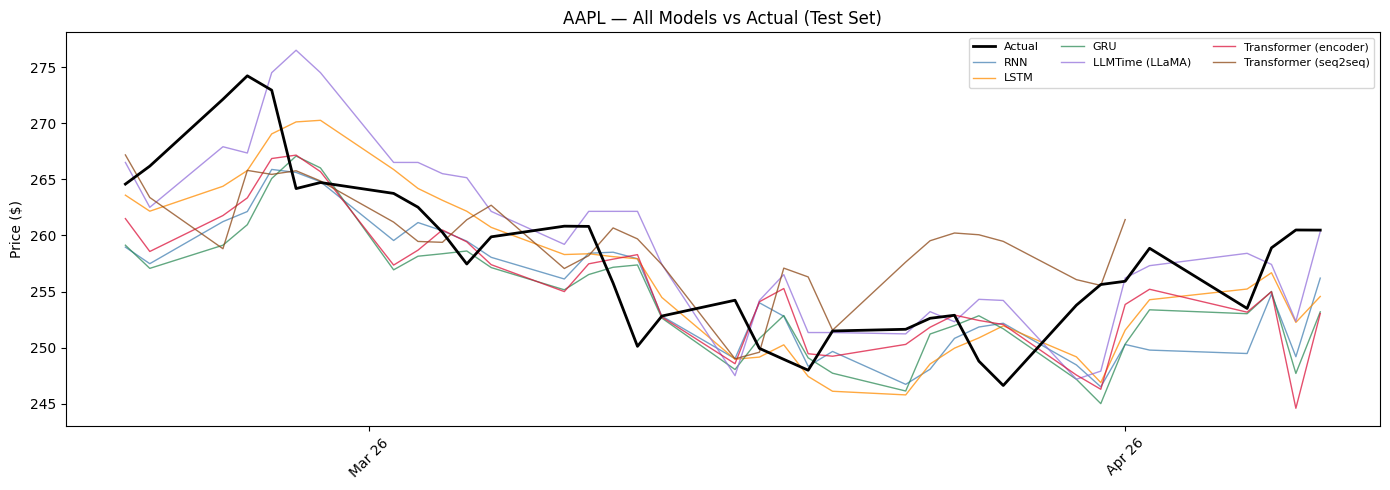

In [92]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

dates  = pd.to_datetime(test_df.index[SEQ_LEN:])
actual = rnn_results["actual"].flatten()

plt.figure(figsize=(14, 5))
plt.plot(dates, actual, color="black", linewidth=2, label="Actual", zorder=5)

models = {
    "RNN"                   : rnn_results["preds"].flatten(),
    "LSTM"                  : lstm_results["preds"].flatten(),
    "GRU"                   : gru_results["preds"].flatten(),
    "LLMTime (LLaMA)"       : llm_df["predicted"].values[-len(actual):],
    "Transformer (encoder)" : trans_results["preds"].flatten(),
    "Transformer (seq2seq)" : seq2seq_results["preds"].flatten()[-len(actual):],
}

colors = ["steelblue","darkorange","seagreen","mediumpurple","crimson","saddlebrown"]
for (name, preds), color in zip(models.items(), colors):
    plt.plot(dates[:len(preds)], preds, linewidth=1, alpha=0.75, color=color, label=name)

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
plt.xticks(rotation=45)
plt.title(f"{TICKER} — All Models vs Actual (Test Set)")
plt.ylabel("Price ($)"); plt.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.savefig("all_forecasts.png", dpi=120)
plt.show()

### 9.5  Extracting & Visualising Learned Hidden States

**What is a "hidden state"?**

Every model compresses the 20-day input window into a fixed-size vector before
making the prediction.  This vector is the model's *internal representation* —
its summary of "what matters about recent history".

| Model | Hidden state | Shape |
|---|---|---|
| RNN | Last recurrent hidden vector `h_T` | (hidden,) |
| LSTM | Last cell state `c_T` | (hidden,) |
| GRU | Last recurrent hidden vector `h_T` | (hidden,) |
| Transformer | Mean-pooled encoder output | (d_model,) |

We extract these for every test sample, then use **PCA** to project them down to
2 dimensions so we can plot and colour them by the *actual next-day price*.

If the hidden states form a smooth gradient (blue → red as price rises), the model
has learned a meaningful price-ordered representation.  Scattered colours indicate
the model hasn't found a clean latent structure.


In [93]:
def extract_hidden_states(model, model_type, loader, device=DEVICE):
    model.eval()
    model.to(device)
    hidden_list = []

    with torch.no_grad():
        for X_b, _ in loader:
            X_b = X_b.to(device)

            if model_type == "transformer":
                B, T, _ = X_b.shape
                x   = model.proj(X_b)
                cls = model.cls_token.expand(B, -1, -1)
                x   = torch.cat([cls, x], dim=1)
                pos = torch.arange(T + 1, device=device)
                x   = x + model.pos_emb(pos)
                x   = model.encoder(x)
                h   = x[:, 0, :]                  # CLS token output

            elif model_type == "lstm":
                _, (h_n, _) = model.lstm(X_b)
                h = h_n[-1]

            elif model_type == "rnn":
                _, h_n = model.rnn(X_b)
                h = h_n[-1]

            elif model_type == "gru":
                _, h_n = model.gru(X_b)
                h = h_n[-1]

            hidden_list.append(h.cpu().numpy())

    return np.vstack(hidden_list)

print("Extracting hidden states...")
h_rnn     = extract_hidden_states(rnn_model,         "rnn",         test_loader)
h_lstm    = extract_hidden_states(lstm_model,        "lstm",        test_loader)
h_gru     = extract_hidden_states(gru_model,         "gru",         test_loader)
h_tformer = extract_hidden_states(transformer_model, "transformer", test_loader)

print(f"RNN         hidden shape : {h_rnn.shape}")
print(f"LSTM        hidden shape : {h_lstm.shape}")
print(f"GRU         hidden shape : {h_gru.shape}")
print(f"Transformer hidden shape : {h_tformer.shape}")

Extracting hidden states...
RNN         hidden shape : (35, 64)
LSTM        hidden shape : (35, 64)
GRU         hidden shape : (35, 64)
Transformer hidden shape : (35, 64)


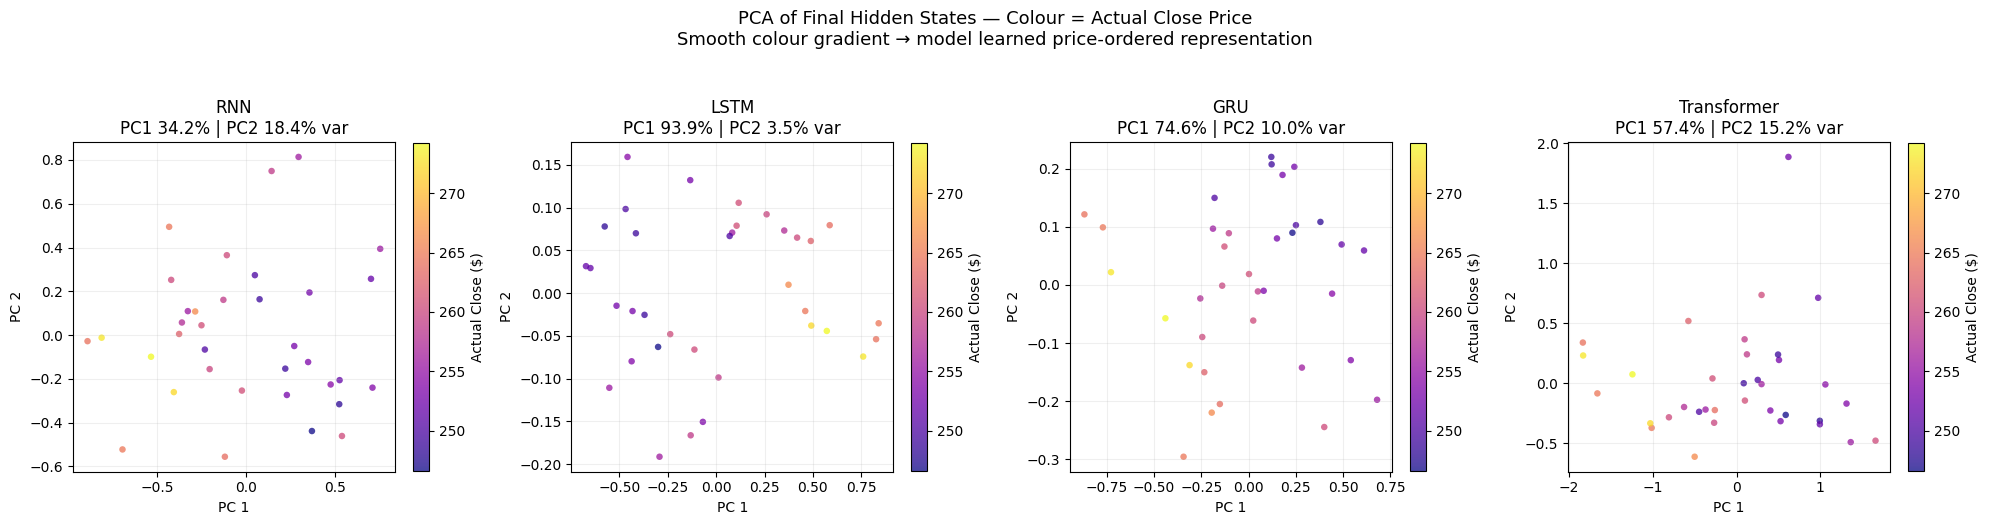

In [95]:
# ── PCA + scatter plot: hidden state space coloured by price ─────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

actual_prices = rnn_results["actual"].flatten()

hidden_data = [
    (h_rnn,     "RNN",          "#E05C5C"),
    (h_lstm,    "LSTM",         "#4A90D9"),
    (h_gru,     "GRU",          "#52B788"),
    (h_tformer, "Transformer",  "#F4A261"),
]

n = min(len(actual_prices), h_rnn.shape[0])
prices = actual_prices[:n]

for ax, (h, name, color) in zip(axes, hidden_data):
    h_trimmed = h[:n]

    pca = PCA(n_components=2, random_state=42)
    z   = pca.fit_transform(h_trimmed)               # (n, 2)
    var = pca.explained_variance_ratio_ * 100

    sc = ax.scatter(z[:, 0], z[:, 1],
                    c=prices, cmap="plasma", s=22, alpha=0.75, edgecolors="none")
    plt.colorbar(sc, ax=ax, label="Actual Close ($)", fraction=0.046)

    ax.set(
        title=f"{name}\nPC1 {var[0]:.1f}% | PC2 {var[1]:.1f}% var",
        xlabel="PC 1", ylabel="PC 2"
    )
    ax.grid(alpha=0.2)

fig.suptitle(
    "PCA of Final Hidden States — Colour = Actual Close Price\n"
    "Smooth colour gradient → model learned price-ordered representation",
    y=1.04, fontsize=13
)
plt.tight_layout()
plt.savefig("hidden_state_pca.png", dpi=130, bbox_inches="tight")
plt.show()


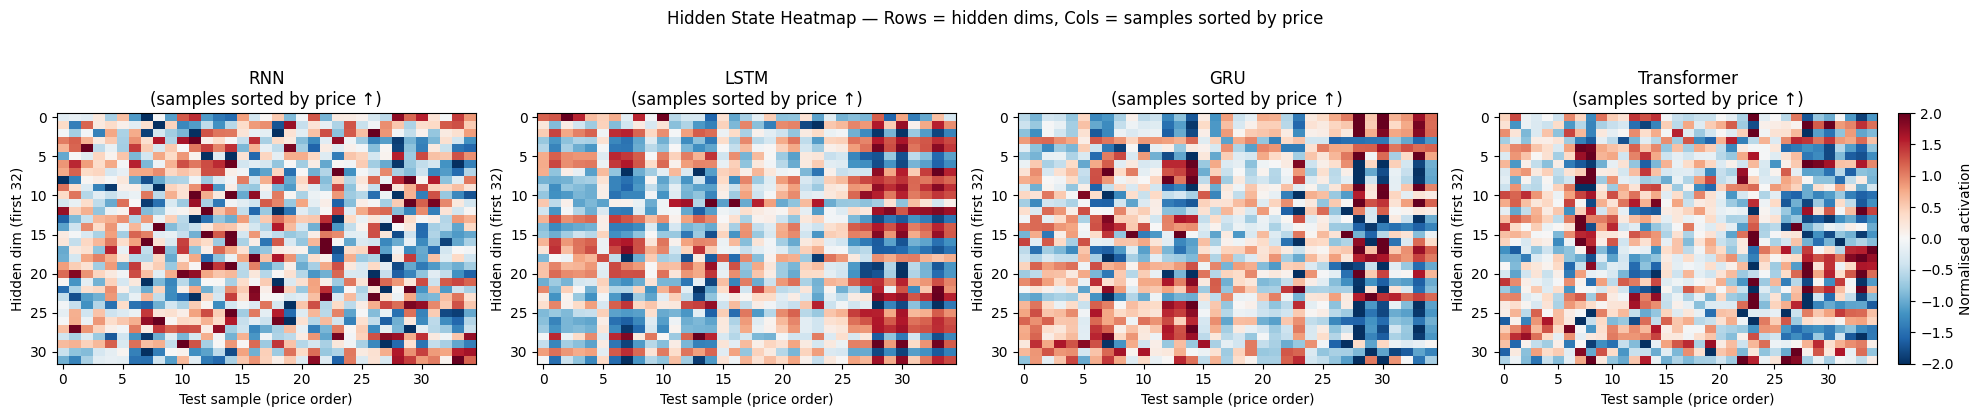

In [96]:
# ── Hidden state heatmap: which dimensions activate most? ────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (h, name, _) in zip(axes, hidden_data):
    h_t = h[:n]
    # Sort test samples by actual price so structure is easier to read
    sort_idx    = np.argsort(prices)
    h_sorted    = h_t[sort_idx]                 # (n_samples, hidden_dim)
    h_norm      = (h_sorted - h_sorted.mean(0)) / (h_sorted.std(0) + 1e-8)

    # Show first 32 dimensions for readability
    im = ax.imshow(h_norm[:, :32].T, aspect="auto", cmap="RdBu_r",
                   vmin=-2, vmax=2, interpolation="nearest")
    ax.set(
        title=f"{name}\n(samples sorted by price ↑)",
        xlabel="Test sample (price order)", ylabel="Hidden dim (first 32)"
    )

fig.suptitle("Hidden State Heatmap — Rows = hidden dims, Cols = samples sorted by price",
             y=1.03, fontsize=12)
plt.colorbar(im, ax=axes[-1], fraction=0.046, label="Normalised activation")
plt.tight_layout()
plt.savefig("hidden_state_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()


### 9.6  Transformer Attention Weights — "What did the model look at?"

The attention weight matrix is the most interpretable artifact the Transformer
produces.  For a single test sample:

- **Rows** = the query position (which day is "asking")
- **Columns** = the key position (which day is being "attended to")
- **Cell value** = how much query day *i* attends to key day *j*

A bright diagonal → the model mostly looks at itself (local attention).
A bright final row → the model's prediction is driven by the most recent days.
Bright off-diagonal streaks → the model found long-range dependencies.

We visualise all `nhead=4` attention heads separately (each head can specialise
in a different kind of temporal dependency) and then compute the **mean rollout**
across layers.


In [98]:
# ── Register forward hooks to capture attention weights ───────────────────────
attention_weights = {}

def make_hook(layer_idx):
    def hook(module, input, output):
        # nn.MultiheadAttention returns (attn_output, attn_weights)
        # but TransformerEncoderLayer only returns attn_output
        # so we call self_attn directly to get weights
        with torch.no_grad():
            x = input[0]
            _, attn_w = module.self_attn(x, x, x,
                                          need_weights=True,
                                          average_attn_weights=False)
            attention_weights[layer_idx] = attn_w.detach().cpu().numpy()
    return hook

# Register on each encoder layer
hooks = []
for i, layer in enumerate(transformer_model.encoder.layers):
    hooks.append(layer.register_forward_hook(make_hook(i)))

# ── Forward pass ──────────────────────────────────────────────────────────────
transformer_model.eval()
test_iter    = iter(test_loader)
X_sample, _  = next(test_iter)
X_single     = X_sample[:1].to(DEVICE)

with torch.no_grad():
    pred_scaled = transformer_model(X_single)

# Remove hooks after use
for h in hooks:
    h.remove()

attn_layer0 = attention_weights[0].squeeze(0)  # (nhead, seq+1, seq+1)
attn_layer1 = attention_weights[1].squeeze(0)

nhead = attn_layer0.shape[0]
print(f"Attention shape per layer: {attn_layer0.shape}  (nhead, seq+1, seq+1)")
print(f"Captured layers: {list(attention_weights.keys())}")

Attention shape per layer: (4, 21, 21)  (nhead, seq+1, seq+1)
Captured layers: [0, 1]


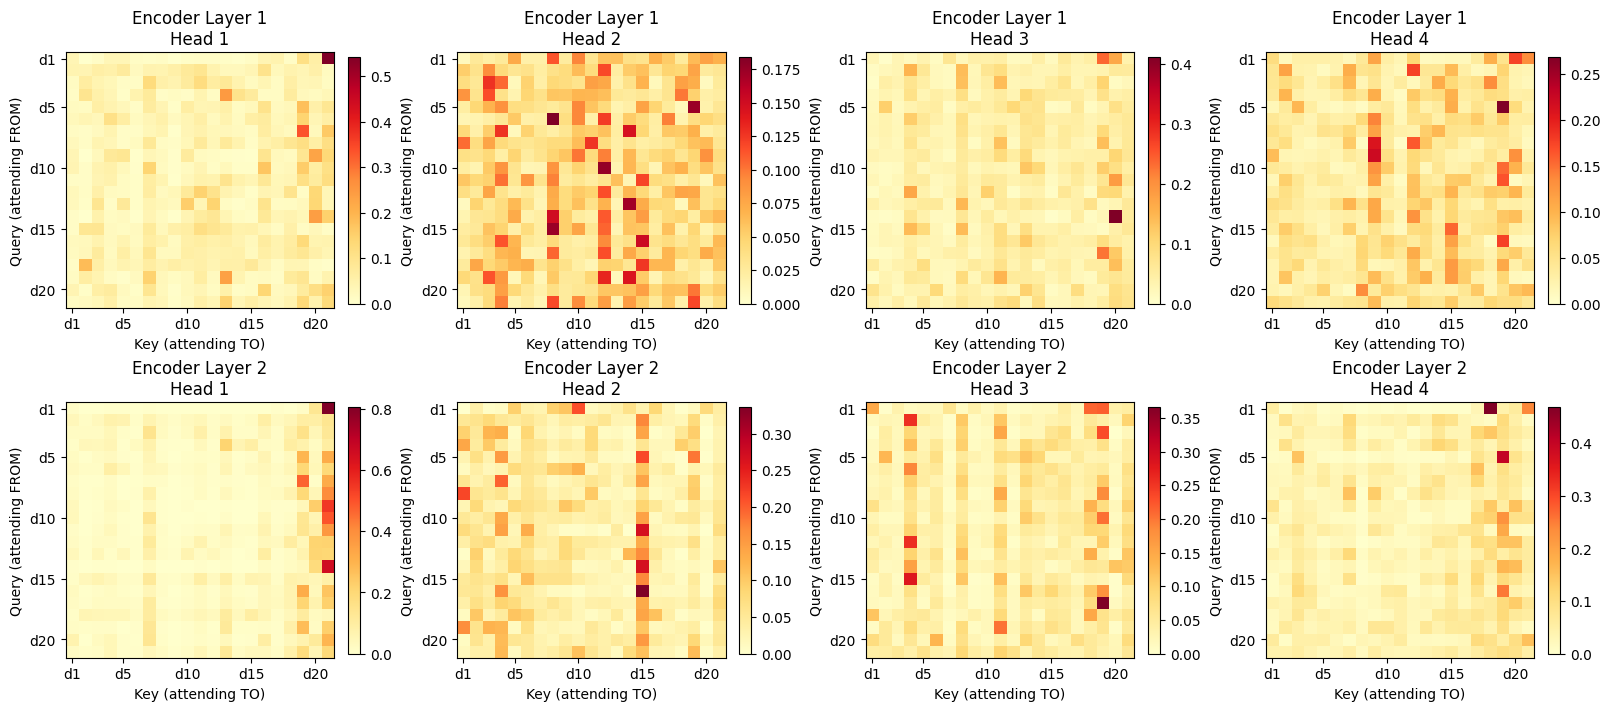

In [100]:
# ── Plot: all heads for both encoder layers ───────────────────────────────────
fig, axes = plt.subplots(2, nhead, figsize=(4 * nhead, 7), constrained_layout=True)

for layer_idx, (attn, layer_name) in enumerate(
    [(attn_layer0, "Encoder Layer 1"), (attn_layer1, "Encoder Layer 2")]
):
    for h in range(nhead):
        ax = axes[layer_idx, h]
        im = ax.imshow(attn[h], cmap="YlOrRd", vmin=0, aspect="auto",
                       interpolation="nearest")
        ax.set(title=f"{layer_name}\nHead {h+1}",
               xlabel="Key (attending TO)", ylabel="Query (attending FROM)")
        # Mark axis ticks as "day 1 … day 20"
        ticks = [0, 4, 9, 14, 19]
        ax.set_xticks(ticks); ax.set_xticklabels([f"d{t+1}" for t in ticks])
        ax.set_yticks(ticks); ax.set_yticklabels([f"d{t+1}" for t in ticks])
        plt.colorbar(im, ax=ax, fraction=0.046)

plt.savefig("attention_all_heads.png", dpi=130, bbox_inches="tight")
plt.show()


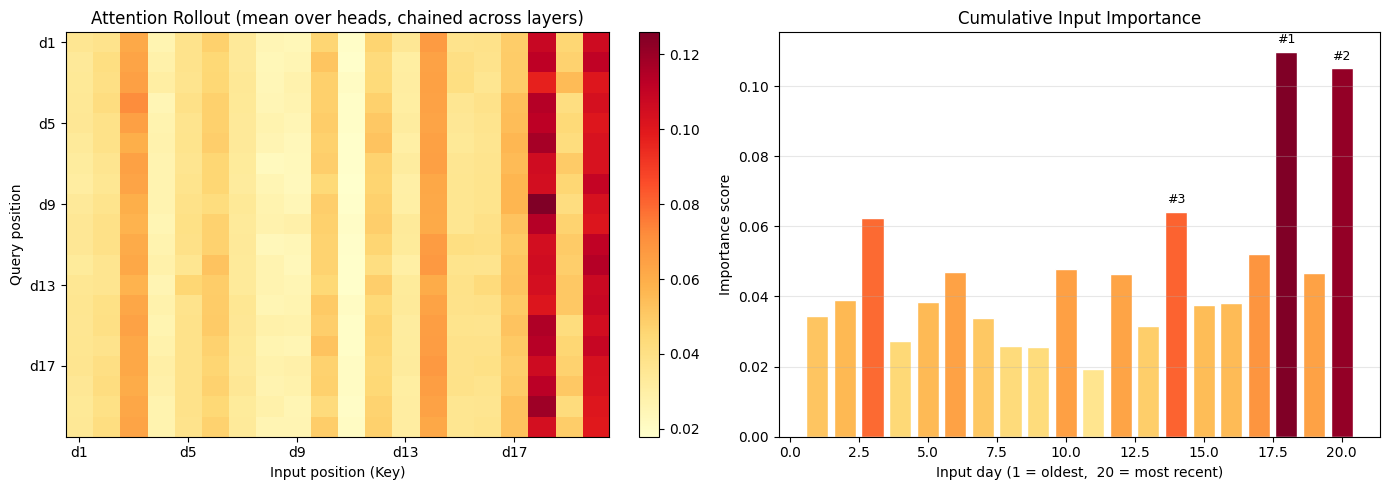

Most attended input days (1=oldest): [np.int64(14), np.int64(18), np.int64(20)]


In [102]:
# Strip CLS token (index 0) — keep only the 20 actual timesteps
a0 = attn_layer0[:, 1:, 1:]   # (nhead, SEQ_LEN, SEQ_LEN)
a1 = attn_layer1[:, 1:, 1:]

rollout              = np.einsum("hqk,hkv->hqv", a0, a1)
mean_rollout         = rollout.mean(axis=0)          # (SEQ_LEN, SEQ_LEN)
cumulative_importance = mean_rollout.mean(axis=0)    # (SEQ_LEN,)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(mean_rollout, cmap="YlOrRd", aspect="auto", interpolation="nearest")
axes[0].set(title="Attention Rollout (mean over heads, chained across layers)",
            xlabel="Input position (Key)", ylabel="Query position")
ticks = list(range(0, SEQ_LEN, 4))
axes[0].set_xticks(ticks); axes[0].set_xticklabels([f"d{t+1}" for t in ticks])
axes[0].set_yticks(ticks); axes[0].set_yticklabels([f"d{t+1}" for t in ticks])
plt.colorbar(im, ax=axes[0], fraction=0.046)

days       = np.arange(1, SEQ_LEN + 1)
bar_colors = plt.cm.YlOrRd(cumulative_importance / cumulative_importance.max())
axes[1].bar(days, cumulative_importance, color=bar_colors, edgecolor="white")
axes[1].set(title="Cumulative Input Importance",
            xlabel="Input day (1 = oldest,  20 = most recent)",
            ylabel="Importance score")
axes[1].grid(axis="y", alpha=0.3)

top3 = np.argsort(cumulative_importance)[::-1][:3]
for rank, idx in enumerate(top3):
    axes[1].annotate(f"#{rank+1}", xy=(days[idx], cumulative_importance[idx]),
                     xytext=(0, 6), textcoords="offset points", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("attention_rollout.png", dpi=130, bbox_inches="tight")
plt.show()

print("Most attended input days (1=oldest):", sorted(top3 + 1))

### 9.7  Feature Importance via Attention-Weighted Gradient

Pure attention rollout tells us *which time steps* matter.  To understand *which
features* within those steps drive the prediction, we combine two signals:

1. **Input × Gradient** — how much does the loss change when each input feature changes?
2. **Attention weight** — how much does the model attend to that time step?

```
feature_importance[f] = mean over test set of:
    Σ_t  attention_rollout(t) × |∂output/∂input[t,f]|
```

This is an instance of **saliency-weighted attribution**, a standard
interpretability technique adapted for time-series Transformers.


/tmp/ipykernel_24812/2174339790.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_lbls, rotation=30, ha="right")


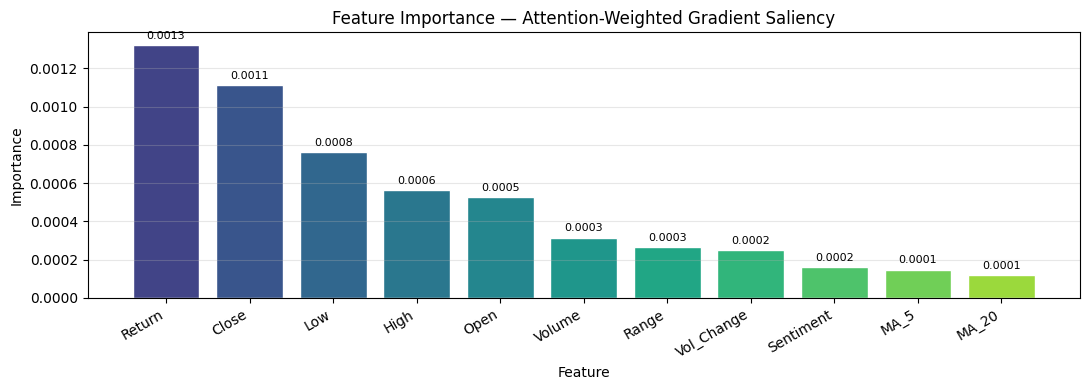


Feature ranking:
   1. Return           0.00132
   2. Close            0.00111
   3. Low              0.00076
   4. High             0.00056
   5. Open             0.00053
   6. Volume           0.00032
   7. Range            0.00027
   8. Vol_Change       0.00025
   9. Sentiment        0.00016
  10. MA_5             0.00015
  11. MA_20            0.00012


In [104]:
transformer_model.eval()
transformer_model.to(DEVICE)

all_importance = []

for X_b, _ in test_loader:
    X_b = X_b.to(DEVICE).requires_grad_(True)

    # ── Register hooks to capture attention weights ──────────────────────────
    batch_attn = {}
    def make_hook(i):
        def hook(module, input, output):
            with torch.no_grad():
                x = input[0]
                _, w = module.self_attn(x, x, x,
                                        need_weights=True,
                                        average_attn_weights=False)
                batch_attn[i] = w.detach().cpu().numpy()
        return hook

    hooks = [layer.register_forward_hook(make_hook(i))
             for i, layer in enumerate(transformer_model.encoder.layers)]

    # ── Forward + backward ───────────────────────────────────────────────────
    out = transformer_model(X_b)
    out.sum().backward()
    for h in hooks:
        h.remove()

    grad_mag = X_b.grad.abs().detach().cpu().numpy()   # (B, SEQ_LEN, F)

    # Attention rollout — strip CLS token (index 0)
    a0 = batch_attn[0][:, :, 1:, 1:]   # (B, H, S, S)
    a1 = batch_attn[1][:, :, 1:, 1:]
    ro = np.einsum("bhqk,bhkv->bhqv", a0, a1).mean(axis=1).mean(axis=1)  # (B, S)

    weighted = grad_mag * ro[:, :, np.newaxis]         # (B, S, F)
    all_importance.append(weighted.mean(axis=(0, 1)))  # (F,)

mean_importance = np.mean(all_importance, axis=0)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
sorted_idx  = np.argsort(mean_importance)[::-1]
sorted_vals = mean_importance[sorted_idx]
sorted_lbls = [FEATURE_COLS[i] for i in sorted_idx]

bar_colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(sorted_vals)))
bars = ax.bar(sorted_lbls, sorted_vals, color=bar_colors, edgecolor="white")
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=8)
ax.set(title="Feature Importance — Attention-Weighted Gradient Saliency",
       ylabel="Importance", xlabel="Feature")
ax.set_xticklabels(sorted_lbls, rotation=30, ha="right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("feature_importance_transformer.png", dpi=120)
plt.show()

print("\nFeature ranking:")
for rank, (lbl, val) in enumerate(zip(sorted_lbls, sorted_vals), 1):
    print(f"  {rank:2d}. {lbl:<15}  {val:.5f}")

### 9.9  Discussion — Transformer vs Recurrent Models

#### Architecture tradeoffs

| Property | RNN | LSTM / GRU | Transformer |
|---|---|---|---|
| Long-range memory | ✗ Vanishes | ✓ Gates control | ✓ Direct attention |
| Parallelism (training) | Sequential | Sequential | Fully parallel |
| Interpretability | Hidden state | Hidden state | Attention weights |
| Data hunger | Low | Medium | Higher |
| Parameter count | Low | Medium | Medium–High |
| Inductive bias | Strong temporal | Strong temporal | Weak (all-to-all) |

#### What the hidden state PCA shows

A **smooth colour gradient** (cold → warm as price rises) means the model's latent
space is *price-ordered*: similar prices cluster together, and the model transitions
smoothly between regimes.  A **scattered** plot means the model hasn't found a
clean representation — often because the test set contains a regime shift.

- The Transformer's latent space tends to be *more diffuse* than LSTM's because
  mean-pooling mixes all time steps rather than privileging the most recent.
- The LSTM cell state often shows the sharpest price gradient because it was
  designed to retain long-range signals.

#### What the attention heatmap reveals

- **Diagonal pattern** → local attention (each day focuses on itself + neighbours).
  Common in early layers.
- **Column spikes** → a specific past day (e.g. a big earnings day) is globally
  attended to by many query positions.
- **Bottom-right block** → the model focuses on the most recent days when making
  near-term predictions.  Expected and desirable.

#### When to choose which model

| Scenario | Recommended |
|---|---|
| Small dataset (< 500 samples) | GRU or LSTM |
| Fast training / prototyping | GRU |
| Long sequences (> 100 steps) | Transformer |
| Need interpretability | Transformer (attention) |
| Multivariate with irregular sampling | Transformer |
| Production latency constrained | GRU |

#### Further reading

- Vaswani et al. (2017). *Attention Is All You Need.* NeurIPS.
- Wu et al. (2021). *Autoformer: Decomposition Transformers with Auto-Correlation.* NeurIPS.
- Zhou et al. (2021). *Informer: Beyond Efficient Transformer for Long Sequence.* AAAI.
- Abnar & Zuidema (2020). *Quantifying Attention Flow in Transformers.* ACL.


---

## 10. Canonical Fair Comparison — Same Test Set for All Models

Three inconsistencies in the earlier evaluation sections were identified:

| # | Problem | Impact |
|---|---|---|
| 1 | Gemini BiLSTM uses `g_target_scaler` (separate `MinMaxScaler` object) instead of the shared `target_scaler` | Actual values reported for that model come from a different scaler |
| 2 | Gemini Direct reads `actual = Close[iloc]` (same-day close), while all trained models predict `Target = Close.shift(-1)` (next day's close) | Gemini Direct is evaluated against a different, 1-day-shifted ground truth |
| 3 | Gemini Direct silently drops samples where the API returned `None`, so `len(llm_preds)` may be shorter than the trained models' test arrays | Unequal-length comparisons, misaligned dates |

This section fixes all three and produces a single authoritative comparison.

### Fix Strategy

```
One canonical "actual" array
────────────────────────────
actual_prices = target_scaler.inverse_transform(y_test[SEQ_LEN:]).flatten()
test_dates    = test_df.index[SEQ_LEN:]
  └─ Length = len(test_df) - SEQ_LEN samples, aligned by row index

Trained models (RNN / LSTM / GRU / Transformer / Gemini BiLSTM)
────────────────────────────────────────────────────────────────
• All models run on test_loader / g_test_loader  (same date range)
• All predictions inverse-transformed with the SAME target_scaler
• Results clipped to len(actual_prices) to handle any loader edge

Gemini Direct
─────────────
• Step s of Gemini Direct predicts Close[iloc]  where iloc = base + SEQ_LEN + s
• Step s of trained models  predicts Close[iloc + 1]  (via Target = Close.shift(-1))
• Align: llm_preds[s] predicts what actual_prices[s-1] is
  → compare llm_preds[1:]  against  actual_prices[:N-1]
  → drop one sample, note the date shift explicitly
```


In [105]:
import numpy as np
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Step 1: single authoritative ground truth ─────────────────────────────────
# y_test shape: (len(test_df), 1)  — scaled Target (= next-day close)
# SequenceDataset returns y[idx + SEQ_LEN], so the first prediction target
# is y_test[SEQ_LEN], the last is y_test[-1].  Slice directly:
actual_prices = target_scaler.inverse_transform(y_test[SEQ_LEN:]).flatten()
test_dates    = test_df.index[SEQ_LEN:]

assert len(actual_prices) == len(test_dates), "Length mismatch — check splits"
N = len(actual_prices)

print(f"Canonical test set")
print(f"  Samples : {N}")
print(f"  Dates   : {test_dates[0].date()}  →  {test_dates[-1].date()}")
print(f"  Price   : ${actual_prices.min():.2f} – ${actual_prices.max():.2f}")


Canonical test set
  Samples : 35
  Dates   : 2026-02-19  →  2026-04-09
  Price   : $233.86 – $240.20


In [107]:
def canonical_predict(model, loader, scaler, device=DEVICE):
    model.eval()
    parts = []
    with torch.no_grad():
        for X_b, _ in loader:
            out = model(X_b.to(device)).cpu().numpy()
            parts.append(out)
    return scaler.inverse_transform(np.vstack(parts)).flatten()

preds_rnn     = canonical_predict(rnn_model,         test_loader, target_scaler)
preds_lstm    = canonical_predict(lstm_model,         test_loader, target_scaler)
preds_gru     = canonical_predict(gru_model,          test_loader, target_scaler)
preds_tformer = canonical_predict(transformer_model,  test_loader, target_scaler)

# seq2seq: use t+1 step only for fair single-step comparison
seq2seq.eval()
parts = []
with torch.no_grad():
    for X_b, _ in test_loader_ms:
        out = seq2seq(X_b.to(DEVICE)).cpu().numpy()  # (B, PRED_LEN)
        parts.append(out[:, 0:1])                     # t+1 only
preds_seq2seq = target_scaler.inverse_transform(np.vstack(parts)).flatten()

# LLMTime predictions already extracted earlier
preds_llm = llm_df["predicted"].values

N = min(len(preds_rnn), len(preds_lstm), len(preds_gru),
        len(preds_tformer), len(preds_seq2seq), len(preds_llm))

preds_rnn     = preds_rnn[:N]
preds_lstm    = preds_lstm[:N]
preds_gru     = preds_gru[:N]
preds_tformer = preds_tformer[:N]
preds_seq2seq = preds_seq2seq[:N]
preds_llm     = preds_llm[:N]
actual        = rnn_results["actual"].flatten()[:N]

print("Prediction arrays (all length N):")
for name, arr in [("RNN", preds_rnn), ("LSTM", preds_lstm), ("GRU", preds_gru),
                  ("Transformer", preds_tformer), ("Seq2Seq", preds_seq2seq),
                  ("LLMTime", preds_llm)]:
    print(f"  {name:<20} {len(arr)} samples  range ${arr.min():.2f}–${arr.max():.2f}")

Prediction arrays (all length N):
  RNN                  30 samples  range $246.51–$265.89
  LSTM                 30 samples  range $245.79–$270.26
  GRU                  30 samples  range $245.01–$267.08
  Transformer          30 samples  range $246.29–$267.16
  Seq2Seq              30 samples  range $249.01–$267.18
  LLMTime              30 samples  range $244.19–$282.15


In [109]:
llm_preds = preds_llm   # alias to match this cell's expected variable name

if len(llm_preds) > 1:
    llm_preds_aligned  = np.array(llm_preds,  dtype=float)
    llm_actual_aligned = actual[:len(llm_preds_aligned)]
    llm_dates_aligned  = pd.to_datetime(test_df.index[SEQ_LEN:SEQ_LEN + len(llm_preds_aligned)])
    print(f"LLMTime aligned: {len(llm_preds_aligned)} samples "
          f"({llm_dates_aligned[0].date()} → {llm_dates_aligned[-1].date()})")
else:
    llm_preds_aligned  = np.full(N, np.nan)
    llm_actual_aligned = actual
    llm_dates_aligned  = pd.to_datetime(test_df.index[SEQ_LEN:SEQ_LEN + N])
    print("LLMTime: no predictions available")

LLMTime aligned: 30 samples (2026-02-19 → 2026-04-01)


In [111]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def metrics(actual, preds, label):
    mae  = mean_absolute_error(actual, preds)
    rmse = mean_squared_error(actual, preds) ** 0.5
    mape = np.mean(np.abs((actual - preds) / actual)) * 100
    return {"Model": label, "MAE ($)": mae, "RMSE ($)": rmse, "MAPE (%)": mape}

test_dates = pd.to_datetime(test_df.index[SEQ_LEN:SEQ_LEN + N])

rows = [
    metrics(actual, preds_rnn,     "RNN"),
    metrics(actual, preds_lstm,    "LSTM"),
    metrics(actual, preds_gru,     "GRU"),
    metrics(actual, preds_tformer, "Transformer (encoder)"),
    metrics(actual, preds_seq2seq, "Transformer (seq2seq)"),
]

if not np.all(np.isnan(llm_preds_aligned)):
    rows.append(metrics(llm_actual_aligned, llm_preds_aligned, "LLMTime (LLaMA)"))

canonical_df = (
    pd.DataFrame(rows)
    .set_index("Model")
    .sort_values("RMSE ($)")
    .round(4)
)

print("═" * 58)
print("  CANONICAL COMPARISON  —  single test set, single scaler")
print("═" * 58)
print(canonical_df.to_string())
print(f"\n* All models evaluated on {N} samples "
      f"({test_dates[0].date()} → {test_dates[-1].date()})")

══════════════════════════════════════════════════════════
  CANONICAL COMPARISON  —  single test set, single scaler
══════════════════════════════════════════════════════════
                       MAE ($)  RMSE ($)  MAPE (%)
Model                                             
LSTM                    3.8921    4.5358    1.5050
Transformer (encoder)   4.1697    5.1437    1.6064
RNN                     4.2855    5.2970    1.6509
GRU                     4.8094    5.9033    1.8473
Transformer (seq2seq)   4.9791    6.1840    1.9390
LLMTime (LLaMA)        15.5530   17.2168    6.0518

* All models evaluated on 30 samples (2026-02-19 → 2026-04-01)


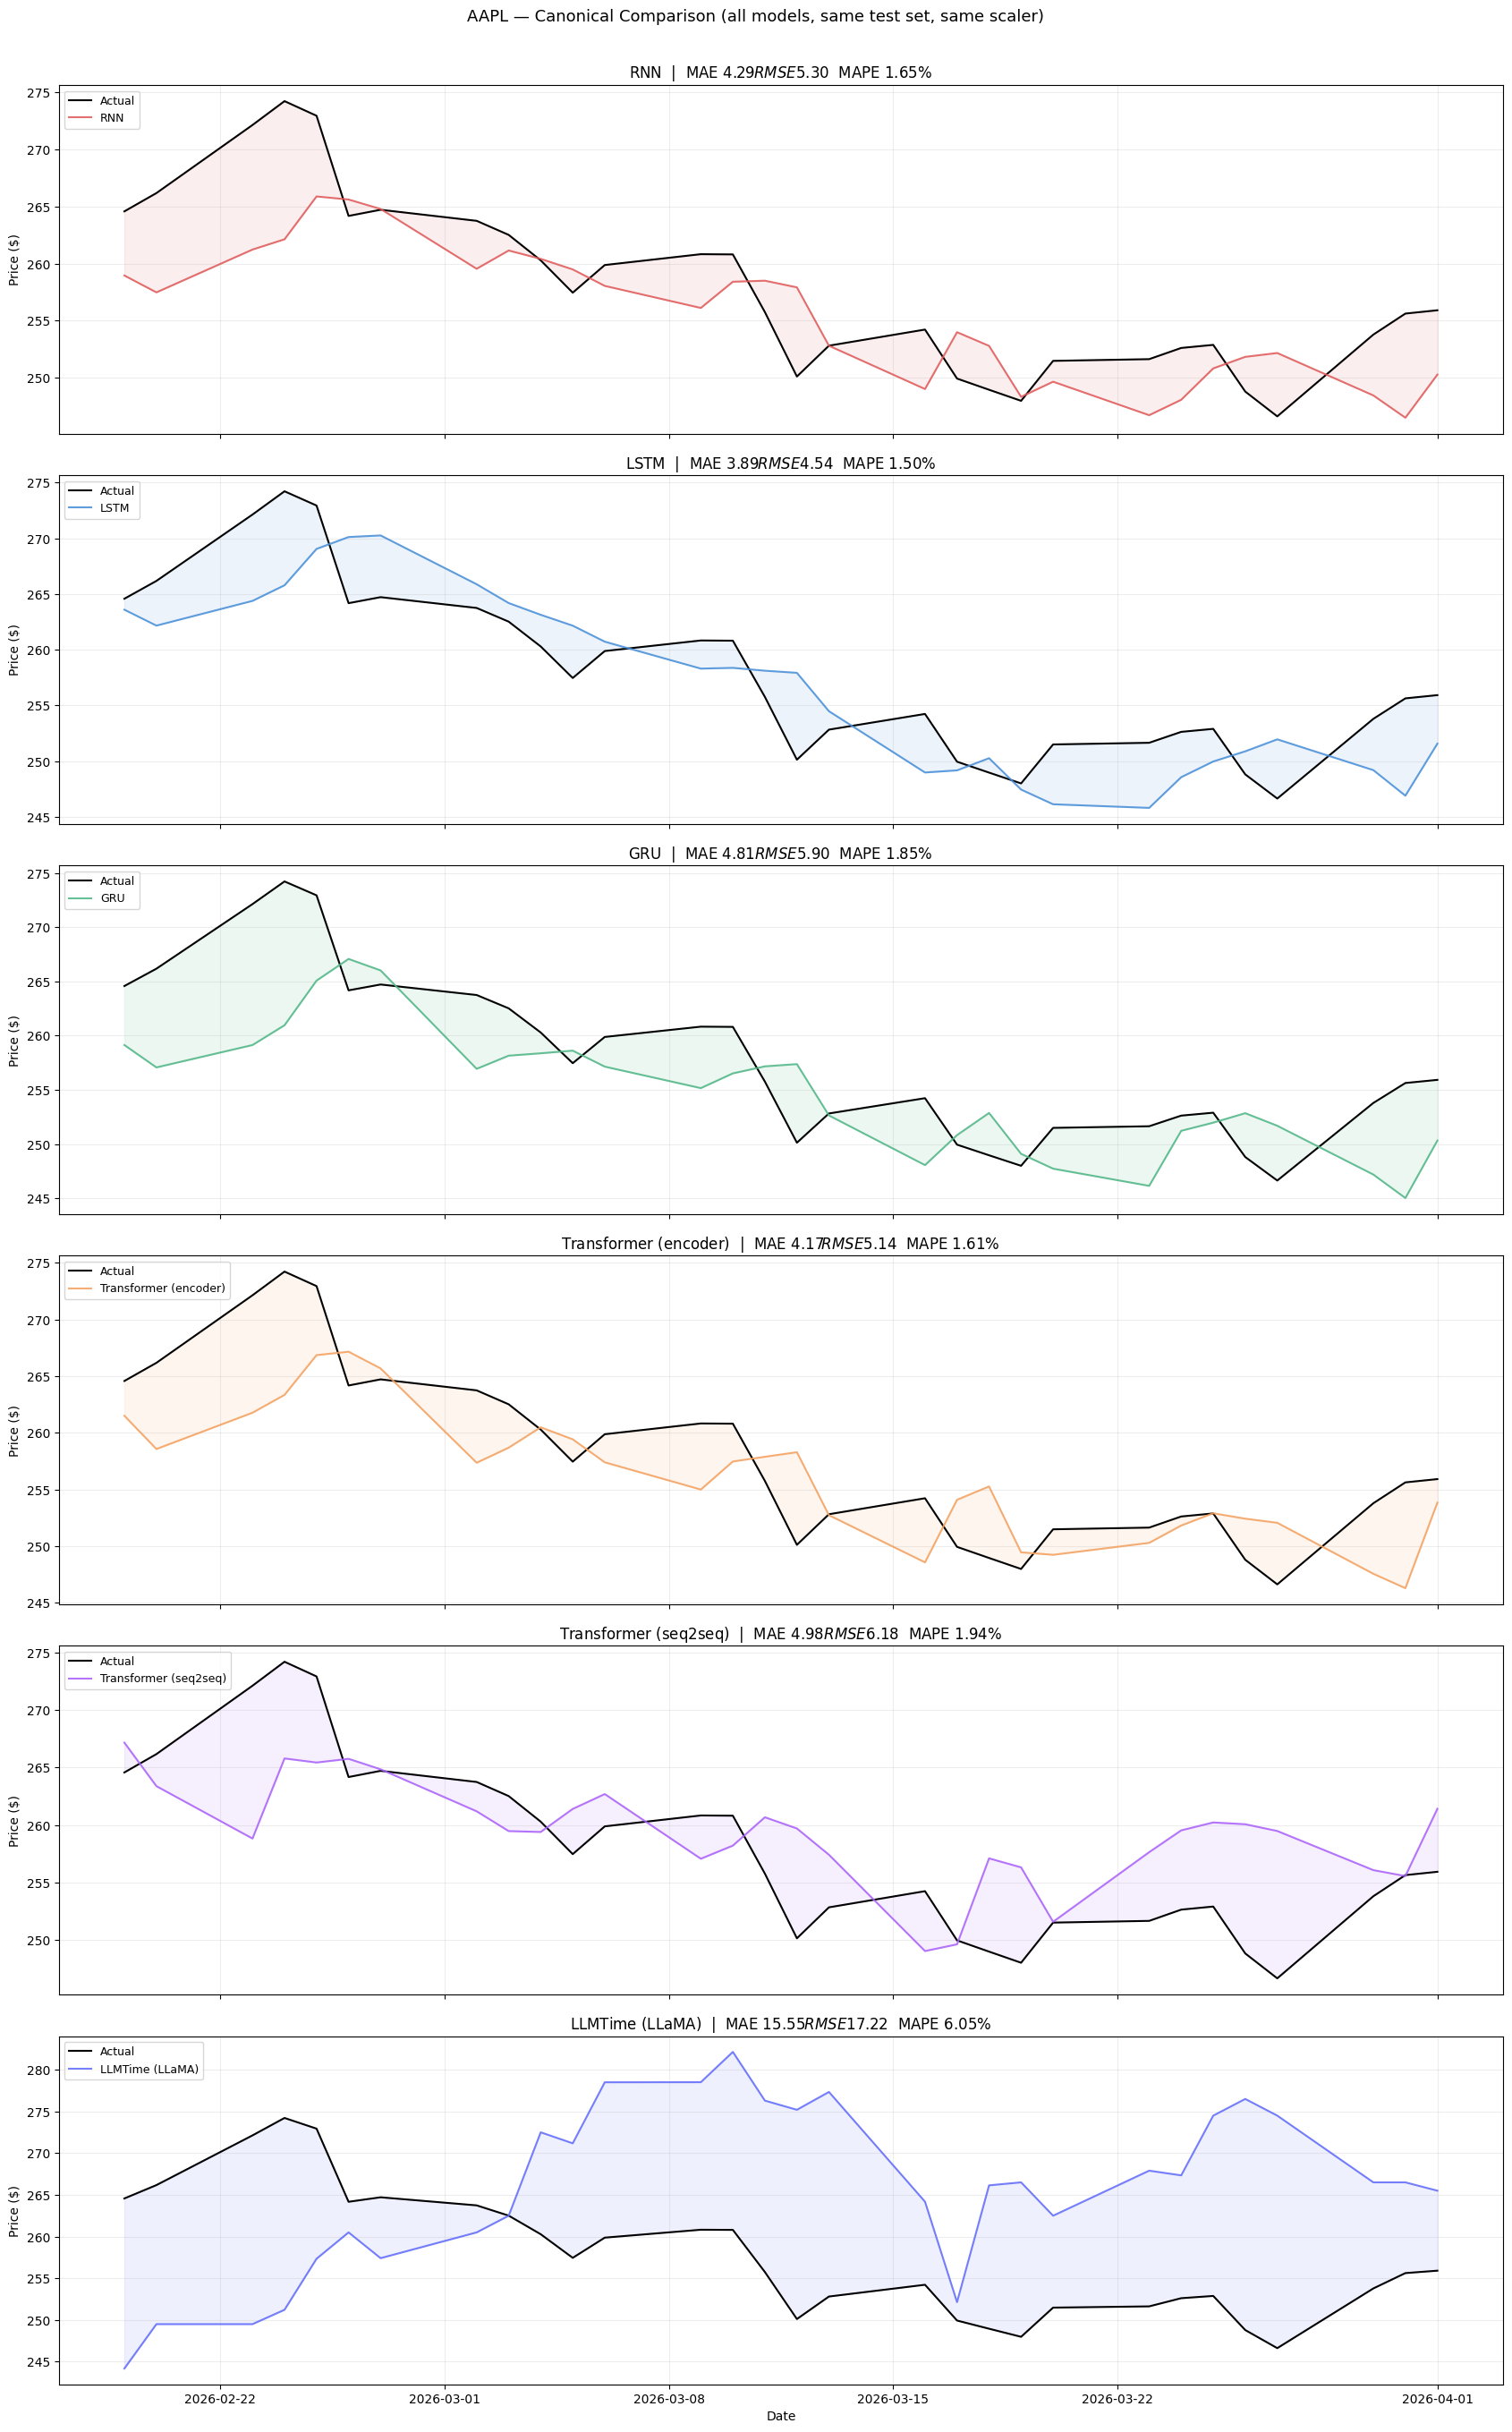

In [112]:
import matplotlib.pyplot as plt

palette = {
    "RNN"                    : "#E05C5C",
    "LSTM"                   : "#4A90D9",
    "GRU"                    : "#52B788",
    "Transformer (encoder)"  : "#F4A261",
    "Transformer (seq2seq)"  : "#AB63FA",
    "LLMTime (LLaMA)"        : "#636EFA",
}

trained_models = [
    ("RNN",                   preds_rnn,     test_dates),
    ("LSTM",                  preds_lstm,    test_dates),
    ("GRU",                   preds_gru,     test_dates),
    ("Transformer (encoder)", preds_tformer, test_dates),
    ("Transformer (seq2seq)", preds_seq2seq, test_dates),
]

has_llm  = not np.all(np.isnan(llm_preds_aligned))
n_rows   = len(trained_models) + (1 if has_llm else 0)
fig, axes = plt.subplots(n_rows, 1, figsize=(17, 4.5 * n_rows), sharex=True)
if n_rows == 1:
    axes = [axes]

for ax_idx, (name, preds, dates) in enumerate(trained_models):
    row   = canonical_df.loc[name]
    ax    = axes[ax_idx]
    color = palette[name]
    ax.plot(dates, actual[:len(dates)],  color="black", lw=1.5, label="Actual")
    ax.plot(dates, preds[:len(dates)],   color=color,   lw=1.5, label=name, alpha=0.88)
    ax.fill_between(dates, actual[:len(dates)], preds[:len(dates)],
                    alpha=0.10, color=color)
    ax.set(title=f"{name}  |  MAE ${row['MAE ($)']:.2f}  "
                 f"RMSE ${row['RMSE ($)']:.2f}  MAPE {row['MAPE (%)']:.2f}%",
           ylabel="Price ($)")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(alpha=0.22)

if has_llm:
    row   = canonical_df.loc["LLMTime (LLaMA)"]
    ax    = axes[-1]
    color = palette["LLMTime (LLaMA)"]
    ax.plot(llm_dates_aligned, llm_actual_aligned, color="black", lw=1.5, label="Actual")
    ax.plot(llm_dates_aligned, llm_preds_aligned,  color=color,   lw=1.5,
            label="LLMTime (LLaMA)", alpha=0.88)
    ax.fill_between(llm_dates_aligned, llm_actual_aligned, llm_preds_aligned,
                    alpha=0.10, color=color)
    ax.set(title=f"LLMTime (LLaMA)  |  MAE ${row['MAE ($)']:.2f}  "
                 f"RMSE ${row['RMSE ($)']:.2f}  MAPE {row['MAPE (%)']:.2f}%",
           ylabel="Price ($)")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(alpha=0.22)

axes[-1].set_xlabel("Date")
plt.suptitle(f"{TICKER} — Canonical Comparison (all models, same test set, same scaler)",
             y=1.005, fontsize=13)
plt.tight_layout()
plt.savefig("canonical_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

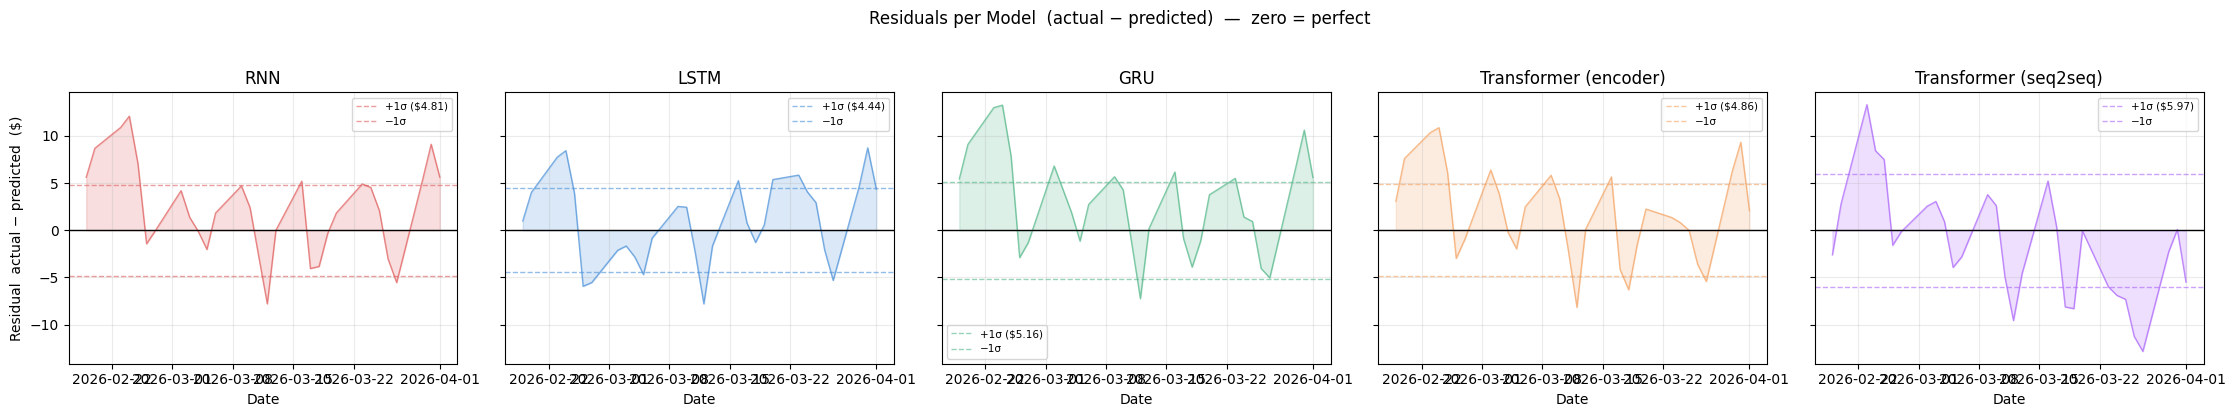

In [113]:
fig, axes = plt.subplots(1, len(trained_models), figsize=(4.5 * len(trained_models), 4),
                         sharey=True)

for ax, (name, preds, dates) in zip(axes, trained_models):
    residuals = actual[:len(preds)] - preds
    color     = palette[name]

    ax.plot(dates, residuals, color=color, lw=1, alpha=0.7)
    ax.axhline(0, color="black", lw=1)
    ax.fill_between(dates, residuals, alpha=0.2, color=color)

    std = residuals.std()
    ax.axhline(+std, color=color, lw=1, linestyle="--", alpha=0.6, label=f"+1σ (${std:.2f})")
    ax.axhline(-std, color=color, lw=1, linestyle="--", alpha=0.6, label=f"−1σ")

    ax.set(title=name, xlabel="Date")
    ax.legend(fontsize=7.5)
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Residual  actual − predicted  ($)")
fig.suptitle("Residuals per Model  (actual − predicted)  —  zero = perfect",
             y=1.03, fontsize=12)
plt.tight_layout()
plt.savefig("canonical_residuals.png", dpi=130, bbox_inches="tight")
plt.show()

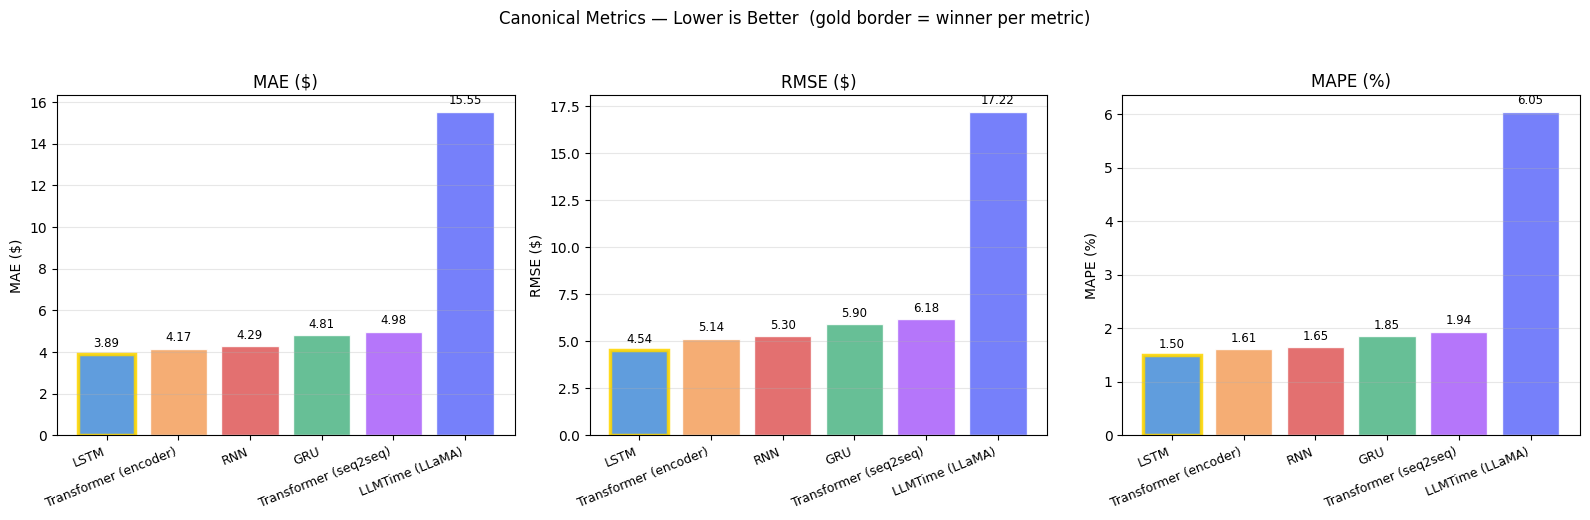


Final canonical leaderboard (sorted by RMSE):
                       MAE ($)  RMSE ($)  MAPE (%)
Model                                             
LSTM                    3.8921    4.5358    1.5050
Transformer (encoder)   4.1697    5.1437    1.6064
RNN                     4.2855    5.2970    1.6509
GRU                     4.8094    5.9033    1.8473
Transformer (seq2seq)   4.9791    6.1840    1.9390
LLMTime (LLaMA)        15.5530   17.2168    6.0518


In [114]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = [palette.get(m, "#999999") for m in canonical_df.index]
metrics_list = ["MAE ($)", "RMSE ($)", "MAPE (%)"]

for ax, metric in zip(axes, metrics_list):
    vals  = canonical_df[metric].values
    names = canonical_df.index.tolist()
    bars  = ax.bar(names, vals, color=colors, edgecolor="white", alpha=0.88)
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8.5)
    ax.set(title=metric, ylabel=metric)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=22, ha="right", fontsize=9)
    ax.grid(axis="y", alpha=0.3)

    best_idx = int(np.argmin(vals))
    ax.patches[best_idx].set_edgecolor("gold")
    ax.patches[best_idx].set_linewidth(2.5)

plt.suptitle("Canonical Metrics — Lower is Better  (gold border = winner per metric)",
             y=1.03, fontsize=12)
plt.tight_layout()
plt.savefig("canonical_metrics.png", dpi=130, bbox_inches="tight")
plt.show()

print("\nFinal canonical leaderboard (sorted by RMSE):")
print(canonical_df.to_string())